## **CQF Exam 3**

# **(I) Project Objectives**
<p>
The objective of this project is to develop a model to predict positive market moves on SPDR Gold Shares (Ticker: GLD) using Machine Learning (ML) techniques.
</p>

<p>
GLD is one of the largest exchange-traded funds (ETF) by asset under management (AUM), designed to track the spot price of physical gold. It was selected for several reasons: the ETF has two decades of trading history with ample data availability, maintains a high daily transaction volume, and its underlying asset is sensitive to macroeconomic factors — making it a strong candidate for ML classification with rich features to explore.
</p>
<p>
A five-year horizon from 2020-01-01 to 2025-12-31 is used, covering multiple macroeconomic regimes including the COVID-19 crash, the zero-rate era, the aggressive rate-hike cycle and the subsequent policy pivot.
</p>
<p>
Short-term asset returns are typically characterized by low-signal to noise ratios, potentially filled with small near-zero returns. Overfitting is therefore key risk, and XGBoost addresses this issue by incorporating a regularized objective function which combines the training loss with explicit penalties on tree structure (γ) and leaf weights (λ), discouraging the model from memorizing the noise in training data. XGBoost also has built-in early stopping, parallel tree construction and ability to handle missing values, making it a well-suited for multi-sourced, large feature sets which will be used in this study.
</p>
<p>
The success criteria is to maximize ROC-AUC. The model will also be evaluated using the F1 score, confusion matrix, and full classification report to identify optimal model parameters. The practical aim is to produce a model that achieves classification accuracy above 50% and generates tradable signals with potential for positive returns after deducting transaction costs.
</p>

## **A) Explanation of Entropy in Classification**
<p>
What does entropy reveal about the quality of the partitions in a classifiation problem?
</p>

Entropy measures the impurity or uncertainty of a partition in a classification problem. The formula is:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

where:
- $C$ = number of classes
- $p_i$ = proportion of observations in class $i$ inside the partition
- $\log_2$ means log base 2
<br>
<p>
For binary classification, where classes are 0 and 1:
</p>
$$H(S) = -p \log_2(p) - (1-p) \log_2(1-p)$$
<br>
where $p$ is the proportion of class 1, and $1-p$ is the proportion of class 0.
<br>
<p>
A pure partition, where all observations belong to one class, entropy equal to zero because the partition is perfectly pure. At the other extreme is when entropy is at max where observations and its split is basically 50/50. </p><br>

| Class mix in partition | Entropy | Meaning |
|:---|:---|:---|
| 100% / 0% i.e. $-1.0\log_2(1.0) - 0\log_2(0)$ | 0 | Pure |
| 90% / 10% i.e. $-0.9\log_2(0.9) - 0.1\log_2(0.1)$ | 0.469 | Mostly pure |
| 70% / 30% i.e. $-0.7\log_2(0.7) - 0.3\log_2(0.3)$ | 0.881 | Some impurity |
| 50% / 50% i.e. $-0.5\log_2(0.5) - 0.5\log_2(0.5)$ | 1.000 | Most impure |

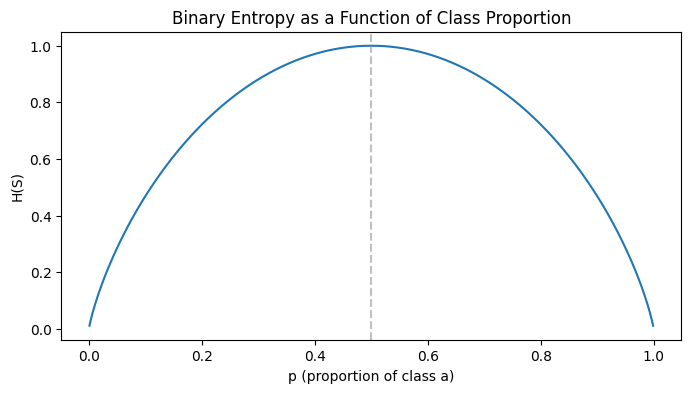

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, H)
plt.xlabel('p (proportion of class a)')
plt.ylabel('H(S)')
plt.title('Binary Entropy as a Function of Class Proportion')
plt.axvline(x=0.5, linestyle='--', color='grey', alpha=0.5)
plt.show()

(a) High entropy means the partitions are pure - **False**
<p>
High entropy in this scenario would mean in the binary classification, classes (0, 1) are almost evenly split, meaning we are uncertain which class an observation should belong to, it is impure. </p>

(b) High entropy means the partitions are impure - **True**
<p>
As we just walked through in the above where high entropy is where classes (0, 1) is observed in different classes. Maximum entropy occurs when classes are evenly split and that signals partitions are impure. A good decision-tree split should reduce entropy in the child nodes, producing higher information gain. The information gain formula is defined as follow:
</p>

$$IG = H(\text{parent}) - \frac{|S_L|}{|S|} H(S_L) - \frac{|S_R|}{|S|} H(S_R)$$

<p>
At every tree split, the algorithm aims to select a split that maximizes IG, driving child nodes toward lower entropy (purer partitions).
</p>

<p>
Applying this to the GLD price direction prediction, each split with XGBoost will seek to separate positive-move days from negative-move days as cleanly as possible, reducing entropy at each node.
</p>


## **(II) Data Collection**

A range of factors impact spot gold and GLD price. Broadly, these are the key categories:

1) Macroeconomic Factors – economic cycles, inflation expectations, central bank reserves and policies, credit conditions

2) Yields/ Currency – policy rates (fed funds), treasury yields across the curve(real and nominal), yield curve shape, USD index, especially majority of gold is transacted in USD

3) Asset Price, Cross-Asset and Positioning – GLD technicals (e.g. momentum, volatility, transaction volume, Bollinger Bands), gold to silver ratio, gold miner (GDX), equity index (SPY), bond ETFs (TLT), options/ futures position (speculative positioning from CFTC COT data)

4) Geopolitics and Risk Sentiment – VIX, equities drawdown, credit spreads (as proxy for market stress), war (e.g. Ukraine, Iran war), central bank policies (often country specific, geopolitical decision to increase gold holdings as a hedge or reserve)

Not all factors are accessible from public data sources, nor are they suitable. For example, certain gold price drivers such as wars, sanctions, central bank policy shifts are one-off/ structural change in nature; supply-side dynamics (e.g. miners output, refinery capacity) impact a much longer horizon. These are either too low in frequency or too lagged for daily directional classification or one-off events which is difficult to model. Therefore we will focus on extracting data from public sources such as Yahoo Finance, Federal Reserve Bank of St. Louis (FRED) and CFTC Commitments of Traders (COT).

Data extraction will cover approximately 5 years, aiming to ensure multiple market regimes are covered (COVID crisis, zero rate period, rate hike cycle, subsequent pivot). Data will be extracted for factors believed to impact the underlying asset, with features to be engineered after data extraction, initial EDA but before funneling into a more realistic features pipeline.


Full feature list includes:

| Source | Series | Description | Theme |
|:-------|:-------|:------------|:------|
| Yahoo Finance | GLD | SPDR Gold Shares ETF (OHLCV) | Underlying |
| | SLV | iShares Silver Trust | Cross-asset |
| | GDX | VanEck Gold Miners ETF | Cross-asset |
| | TLT | iShares 20+ Year Treasury Bond | Yields |
| | SPY | S&P 500 ETF | Risk sentiment |
| FRED | DGS10 | 10-Year Treasury yield | Yields |
| | DFII10 | 10-Year TIPS yield (real) | Yields |
| | T10YIE | 10-Year breakeven inflation | Macro |
| | T10Y2Y | 10Y–2Y yield curve spread | Yields |
| | DFF | Federal funds effective rate | Macro |
| | DTWEXBGS | Broad trade-weighted USD index | Currency |
| | VIXCLS | CBOE VIX | Risk sentiment |
| | BAMLC0A0CM | ICE BofA US corporate spread | Risk sentiment |
| | DCOILWTICO | WTI crude oil price | Macro |
| CFTC COT | Gold futures | Spec long/short, commercial, OI | Positioning |

**a) Install Packages & Import Libraries**

In [1]:
# Install packages
!pip install -q cot_reports yfinance fredapi
!pip install -q xgboost wandb pyfolio-reloaded
!pip install -q shap
!pip install -q scikit-optimize

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 10.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.2 MB/s eta 0:00:00


In [2]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF")

Mounted at /content/drive


In [3]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf
from fredapi import Fred
from cot_reports import cot_year

# For ML
import shap
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

**b) Data Extraction**

i) Yahoo Finance

In [4]:
# Data Extraction from Yahoo Finance

# Define tickers and date range
tickers     = ['GLD', 'SLV', 'GDX', 'TLT', 'SPY']
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date    = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# GLD: full Adjusted OHLCV (needed for technical features)
df_gld = yf.download('GLD', start=start_date, end=end_date, auto_adjust=True, progress=False)
df_gld.columns = [f'GLD_{col}' for col in df_gld.columns.get_level_values('Price')]

# Cross-asset tickers: Adjusted Close only
cross_tickers = ['SLV', 'GDX', 'TLT', 'SPY']
df_cross = yf.download(cross_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
df_cross.columns = [f'{col}_Close' for col in df_cross.columns]

# Merge into one flat DataFrame and save to google drive
df_yf = pd.concat([df_gld, df_cross], axis=1)
df_yf.to_csv(os.path.join(SAVE_PATH, 'raw_yfinance.csv'))

In [5]:
# High level Data Quality Check
print(f"Shape: {df_yf.shape}")
print(f"Date range: {df_yf.index.min()} to {df_yf.index.max()}")
print(f"\nMissing values:\n{df_yf.isnull().sum()}")

Shape: (1655, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close     0
GLD_High      0
GLD_Low       0
GLD_Open      0
GLD_Volume    0
GDX_Close     0
SLV_Close     0
SPY_Close     0
TLT_Close     0
dtype: int64


In [6]:
print(f"\nColumns: {df_yf.columns.tolist()}")
df_yf.head()


Columns: ['GLD_Close', 'GLD_High', 'GLD_Low', 'GLD_Open', 'GLD_Volume', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close
Date,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727972,13.87,247.342194,108.584053
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820141,13.89,252.711212,107.346024
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900192,106.739288
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078205,13.92,256.557831,107.083672
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096634,14.06,259.125214,108.010147


ii) FRED

In [7]:
# FRED API key from Colab Secrets
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED'))

# Date Parameters
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Define FRED series
fred_series = {
    'DGS10':      '10-Year Treasury Yield',
    'DFII10':     '10-Year TIPS (Real Yield)',
    'T10YIE':     '10-Year Breakeven Inflation',
    'T10Y2Y':     'Yield Curve (10Y-2Y)',
    'DFF':        'Fed Funds Effective Rate',
    'DTWEXBGS':   'Broad Trade-Weighted USD Index',
    'VIXCLS':     'CBOE VIX',
    'BAMLC0A0CM': 'ICE BofA US Corporate Spread',
    'DCOILWTICO': 'WTI Crude Oil',
}

# Download each series
df_fred = pd.DataFrame()
for code, desc in fred_series.items():
    try:
        s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
        df_fred[code] = s
    except Exception as e:
        print(f"  {code:15s} FAILED: {e}")

df_fred.to_csv(os.path.join(SAVE_PATH, 'raw_fred.csv'))

In [8]:
# High level Data Quality Check
print(f"\nShape: {df_fred.shape}")
print(f"Date range: {df_fred.index.min()} to {df_fred.index.max()}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")


Shape: (1718, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-31 00:00:00

Missing values:
DGS10           72
DFII10          72
T10YIE          72
T10Y2Y          72
DFF              0
DTWEXBGS        74
VIXCLS          35
BAMLC0A0CM    1044
DCOILWTICO      72
dtype: int64


In [9]:
print(f"\nColumns: {df_fred.columns.tolist()}")
df_fred.head()


Columns: ['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DTWEXBGS', 'VIXCLS', 'BAMLC0A0CM', 'DCOILWTICO']


,DGS10,DFII10,T10YIE,T10Y2Y,DFF,DTWEXBGS,VIXCLS,BAMLC0A0CM,DCOILWTICO
2019-06-03,2.07,0.34,1.73,0.25,2.38,116.4764,18.86,NaN,53.25
2019-06-04,2.12,0.38,1.74,0.24,2.38,116.0910,16.97,NaN,53.50
2019-06-05,2.12,0.37,1.75,0.29,2.38,116.0300,16.09,NaN,51.57
2019-06-06,2.12,0.39,1.73,0.24,2.37,115.9771,15.93,NaN,52.59
2019-06-07,2.09,0.35,1.74,0.24,2.37,115.7368,16.30,NaN,53.95


iii) CFTC COT

In [10]:
# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Columns to keep and their clean names
cot_cols = {
    'Open Interest (All)'                 :'COT_OI',
    'Noncommercial Positions-Long (All)'  :'COT_Spec_Long',
    'Noncommercial Positions-Short (All)' :'COT_Spec_Short',
    'Commercial Positions-Long (All)'     :'COT_Comm_Long',
    'Commercial Positions-Short (All)'    :'COT_Comm_Short',
}

# Download, filter Gold, select columns
# date range to extract reports
years = range(2019, 2026)

frames = []
for year in years:
    df = cot_year(year, cot_report_type='legacy_fut')
    gold = df[df['Market and Exchange Names'].str.contains('GOLD', case=False)]
    frames.append(gold)

df_cot_gold = (
    pd.concat(frames, ignore_index=True)
    .assign(Date=lambda d: pd.to_datetime(d['As of Date in Form YYYY-MM-DD']))
    .set_index('Date')
    .sort_index()
    [list(cot_cols.keys())]
    .rename(columns=cot_cols)
    .apply(pd.to_numeric, errors='coerce')
)

df_cot_gold.to_csv(os.path.join(SAVE_PATH, 'raw_cot_gold.csv'))

Selected: legacy_fut
Downloaded single year data from: 2019
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2020
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2021
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2022
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2023
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2024
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2025
Stored the file annual.txt in the working directory.


In [11]:
# High level Data Quality Check
print(f"\nShape: {df_cot_gold.shape}")
print(f"Date range: {df_cot_gold.index.min()} to {df_cot_gold.index.max()}")
print(f"\nMissing values:\n{df_cot_gold.isnull().sum()}")


Shape: (492, 5)
Date range: 2019-01-08 00:00:00 to 2025-12-30 00:00:00

Missing values:
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64


In [12]:
df_cot_gold.head()

,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2019-01-08,455232,199560,100344,137605,258792
2019-01-15,501605,201796,113883,179059,287172
2019-01-22,513509,186510,112006,197278,289355
2019-01-29,483390,212318,112725,163922,282531
2019-02-05,479736,218200,109105,157588,288830


c) Data Cleaning

i) Examining NAN values in FRED df

At a first pass, FRED data has NAN values, with BAMLC0A0CM (credit Spread) missing 900+ bars. Investigation required.

In [13]:
print("\nSample of NaN dates across yield series:")
nan_dates = df_fred[df_fred['DGS10'].isnull()].index[:10]
print(nan_dates)

print("\n\nBAMLC0A0CM (credit spread) — first valid date:")
df_fred['BAMLC0A0CM'].first_valid_index()


Sample of NaN dates across yield series:
DatetimeIndex(['2019-07-04', '2019-09-02', '2019-10-14', '2019-11-11',
               '2019-11-28', '2019-12-25', '2020-01-01', '2020-01-20',
               '2020-02-17', '2020-04-10'],
              dtype='datetime64[ns]', freq=None)


BAMLC0A0CM (credit spread) — first valid date:


Timestamp('2023-05-23 00:00:00')

On FRED NAN dates - dates listed above, are non-trading days. This will be adjsuted with ffill, same process for other data sources. <br>

Re BAMLC0A0CM (Credit spread), this data series it not usable for ML training as there is insufficient data, earliest start date only in 2023-05-22 leaving us 2.5 years of data for training and testing. <br>

ICE BofA US High Yield Index Option-Adjusted Spread data has been explored as an alternative. However, we encountered same issue where earliest data availability only starts from 2023-05. <br>

Conclusion: BAMLC0A0CM is dropped from the FRED dataset and replaced with Moody's BAA Corporate Bond Yield (DBAA), The credit spread will become an engineered feature using BAA yield minus 10-Year Treasury. This will be addressed in the feature engineering process.


In [14]:
# Replace credit spread series with Moody's BAA yield
df_fred = df_fred.drop(columns=['BAMLC0A0CM'])
df_fred['DBAA'] = fred.get_series('DBAA', observation_start='2019-12-01', observation_end='2025-12-31')

print(f"Shape: {df_fred.shape}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")

Shape: (1718, 9)

Missing values:
DGS10          72
DFII10         72
T10YIE         72
T10Y2Y         72
DFF             0
DTWEXBGS       74
VIXCLS         35
DCOILWTICO     72
DBAA          198
dtype: int64


In [15]:
print(f"Duplicate dates: {df_cot_gold.index.duplicated().sum()}")
print(f"\nDuplicate rows:")
display(df_cot_gold[df_cot_gold.index.duplicated(keep=False)].head(10))

Duplicate dates: 127

Duplicate rows:


,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2020-12-01,32377,15096,13979,0,0
2020-12-01,538042,324344,64030,110108,403371
2020-12-29,556414,341812,72940,101283,408537
2020-12-29,34210,15798,22384,0,0
2021-05-18,33854,10031,12915,0,0
2021-05-18,520410,290267,91378,121839,354740
2021-08-17,485485,284437,92895,123301,337301
2021-08-17,32480,14107,8528,0,0
2021-09-07,34633,8491,9756,0,0


ii) merge all df together for further data cleaning and pre-processing

In [16]:
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data/'

# Step 1: GLD trading dates = master calendar
master_idx = df_yf.index

# Step 2: Reindex FRED to GLD calendar, forward-fill
df_fred_aligned = df_fred.reindex(master_idx).ffill()

# Step 3: Reindex COT to GLD calendar, forward-fill
# Remove duplicate dates (aggregate if multiple gold contracts per week)
df_cot_dedup = df_cot_gold.groupby(df_cot_gold.index).sum()

# COT is Tuesday snapshot, published Friday — shift forward 4 business days
# so the model first sees it on the following Monday (no lookahead bias)
df_cot_aligned = (
    df_cot_dedup
    .shift(freq=pd.tseries.offsets.BDay(4))  # Tue → next Mon
    .reindex(master_idx)
    .ffill()
)

# Step 4: Merge all into one DataFrame
df_merged = pd.concat([df_yf, df_fred_aligned, df_cot_aligned], axis=1)

In [17]:
# High level data audit
print(f"Shape: {df_merged.shape}")
print(f"Date range: {df_merged.index.min()} to {df_merged.index.max()}")
print(f"\nMissing values:\n{df_merged.isnull().sum()}")
print(f"\nTotal NaN: {df_merged.isnull().sum().sum()}")

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close           0
GLD_High            0
GLD_Low             0
GLD_Open            0
GLD_Volume          0
GDX_Close           0
SLV_Close           0
SPY_Close           0
TLT_Close           0
DGS10               0
DFII10              0
T10YIE              0
T10Y2Y              0
DFF                 0
DTWEXBGS            0
VIXCLS              0
DCOILWTICO          0
DBAA              127
COT_OI              0
COT_Spec_Long       0
COT_Spec_Short      0
COT_Comm_Long       0
COT_Comm_Short      0
dtype: int64

Total NaN: 127


In [18]:
df_merged.head()

,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727972,13.87,247.342194,108.584053,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820141,13.89,252.711212,107.346024,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900192,106.739288,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078205,13.92,256.557831,107.083672,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096634,14.06,259.125214,108.010147,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [20]:
# Sanity check if there are 0 left in columns
print("Zero counts per column:")
print((df_merged == 0).sum())

Zero counts per column:
GLD_Close         0
GLD_High          0
GLD_Low           0
GLD_Open          0
GLD_Volume        0
GDX_Close         0
SLV_Close         0
SPY_Close         0
TLT_Close         0
DGS10             0
DFII10            5
T10YIE            0
T10Y2Y            7
DFF               0
DTWEXBGS          0
VIXCLS            0
DCOILWTICO        0
DBAA              0
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64


In [21]:
# save merged file to data folder
df_merged.to_csv(os.path.join(SAVE_PATH, 'cleaned_merged.csv'))

## **(III) EDA**

In [22]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/cleaned_merged.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00
Missing values: 127


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727972,13.87,247.342194,108.584053,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820141,13.89,252.711212,107.346024,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900192,106.739288,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078205,13.92,256.557831,107.083672,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096634,14.06,259.125214,108.010147,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [23]:
# Descriptive statistics
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
GLD_Close,1655.00,197.61,58.56,125.11,164.92,177.08,215.29,416.74
GLD_High,1655.00,198.48,58.84,125.34,165.65,177.61,216.06,418.45
GLD_Low,1655.00,196.62,58.11,123.90,164.18,176.37,214.44,414.75
GLD_Open,1655.00,197.59,58.54,124.09,165.00,176.96,215.29,416.48
GLD_Volume,1655.00,9201959.70,5354842.78,1436500.00,5807650.00,7888300.00,10935000.00,62025000.00
GDX_Close,1655.00,34.49,11.97,17.64,27.68,31.26,36.43,91.29
SLV_Close,1655.00,23.59,7.38,11.21,19.73,22.20,25.86,71.12
SPY_Close,1655.00,424.54,114.13,204.94,347.72,406.81,507.62,688.50
TLT_Close,1655.00,103.85,19.55,74.27,86.24,94.97,121.08,143.79
DGS10,1655.00,2.85,1.38,0.52,1.57,3.37,4.17,4.98


Descriptive statistics are revealing vastly different scales across the raw columns - from single digit yields percentages to trading volume in millions. This confirms that raw features will need to be transformed, normalized and engineered.

In [24]:
# Verify continuous trading day index (no unexpected gaps)
date_diffs = df.index.to_series().diff().dt.days
print(f"Min gap: {date_diffs.min()} days")
print(f"Max gap: {date_diffs.max()} days")
print(f"\nGap distribution:\n{date_diffs.value_counts().sort_index()}")

Min gap: 1.0 days
Max gap: 4.0 days

Gap distribution:
Date
1.0    1293
2.0      18
3.0     299
4.0      44
Name: count, dtype: int64


A date continuity check confirms no unexpected gaps in the trading day index — observed gaps of 1 to 4 calendar days correspond to weekday, weekend, and holiday patterns.

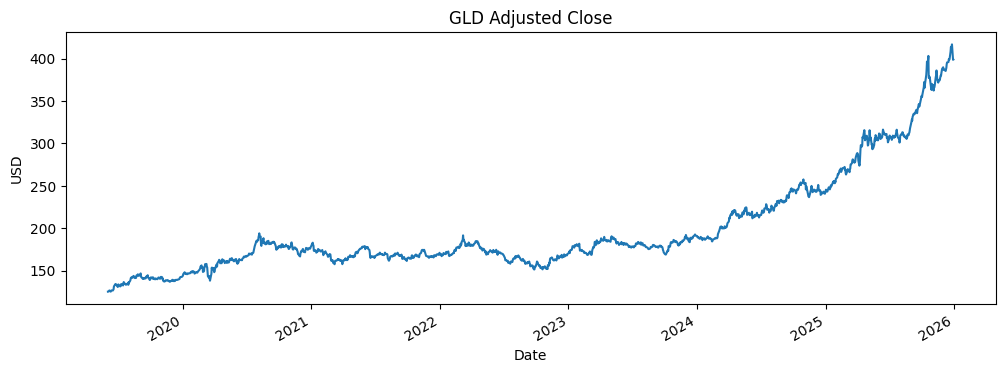

In [25]:
# GLD price history
df['GLD_Close'].plot(figsize=(12, 4), title='GLD Adjusted Close')
plt.ylabel('USD')
plt.show()

GLD has shown an upward trend, paritulcalry from mid-2024 onward. This long bias may result in a class imbalance toward positive returns, which will be examined during label construction.

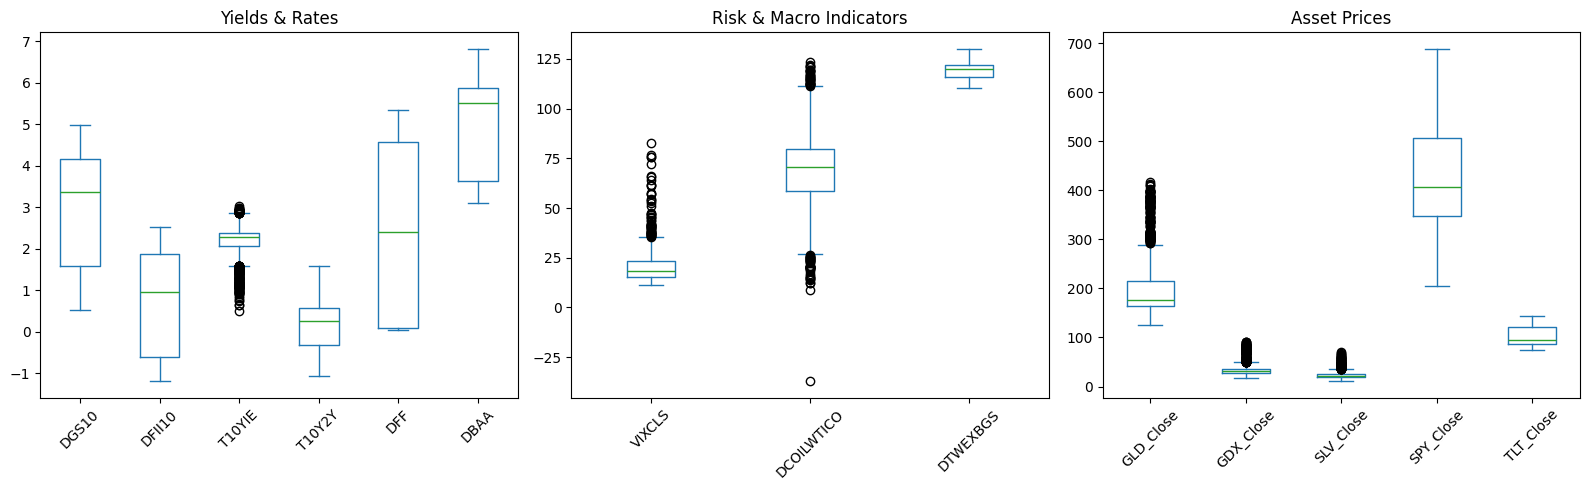

In [26]:
# Box plots — grouped by scale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Yields & rates
df[['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DBAA']].plot.box(ax=axes[0])
axes[0].set_title('Yields & Rates')
axes[0].tick_params(axis='x', rotation=45)

# Risk & macro
df[['VIXCLS', 'DCOILWTICO', 'DTWEXBGS']].plot.box(ax=axes[1])
axes[1].set_title('Risk & Macro Indicators')
axes[1].tick_params(axis='x', rotation=45)

# GLD OHLC only (not volume, not cross-asset)
df[['GLD_Close', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']].plot.box(ax=axes[2])
axes[2].set_title('Asset Prices')
# df[['GLD_Open', 'GLD_High', 'GLD_Low', 'GLD_Close']].plot.box(ax=axes[2])
# axes[2].set_title('GLD Price')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The box plots revealed notable outliers in VIX and Oil (COVID-er spike and WTI going negative in 2020). The assets – GLD, GDX, SLV all showing wide ranges with upper outliers, this matches with price breakthroughs late 2024-2025. SPY’s wide range is a good indicator we have covered different market regimes in the dataset.

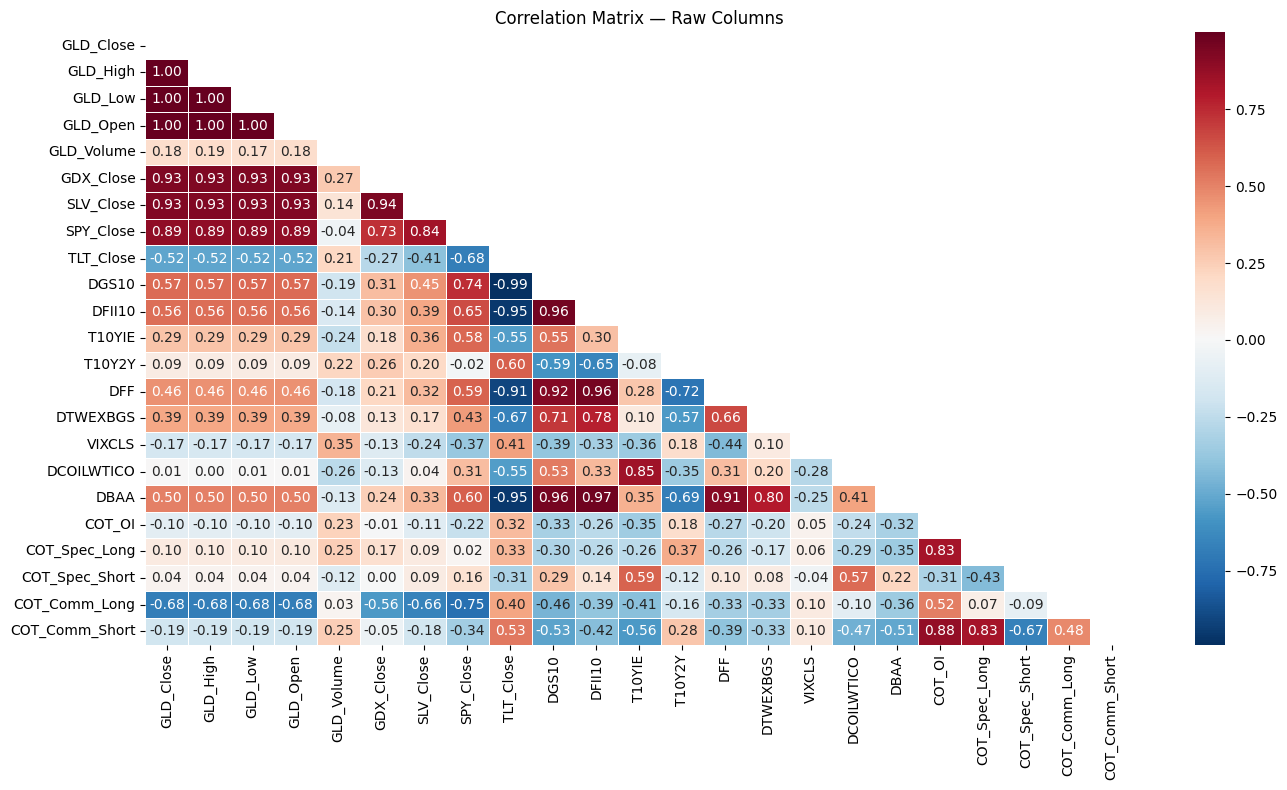

In [27]:
fig, ax = plt.subplots(figsize=(14, 8))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, ax=ax, mask=matrix)
ax.set_title("Correlation Matrix — Raw Columns")
plt.tight_layout()
plt.show()

The raw column correlation matrix is used as an exploratory diagnostic to understand common trends, potentially redundant variables and macro regimes. At this stage, they may not signal predictive relationships. Several observations:

1) potentially redundant variables – GLD OHLC almost identical, reinforcing the need to convert into ratios, returns, z-scores etc in feature engineering and likely to be dropped afterwards
2) potentially high colinear feature groups – Cross asset ETFs, COT variables, rate variables
3) understanding on broad market structure and relationships – TLT and commercial COT positionings are strongly negatively correlated with GLD price

## **(IV) Feature Engineering**

a) Target Variable Construction

Log returns are used to compute asset returns. This transforms non-stationary price series into relative changes that are more comparable across assets with different price scales. It also allows multi-period returns to be obtained by simple summation of single-period log returns. This makes it convenient to compare returns, volatility, momentum and target-label construction.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

To construct the target variable, we first compute daily log returns and first examine and understand the series from these aspects:

1) Are the returns stationary – or does it cluster around volatility clustering and regimes across peirod
2) The returns distribution profile – does it shape around zero, dominated by small moves or it looks choppy and dispersed
3) Statistical behavior – is the return series skewed, biased towards positive/ negative moves or dominated by outliers

These inform the choice of the boundary below which daily returns are treated as noise rather than genuine directional signals, and the resulting binary label assignment


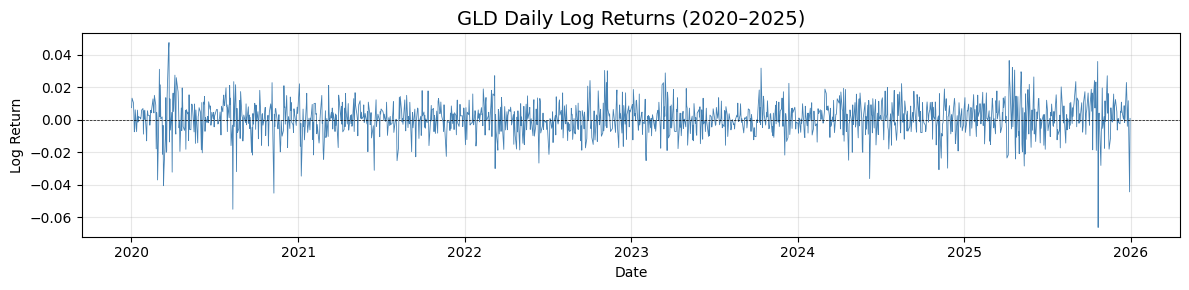

In [28]:
# Compute daily log returns from GLD adjusted close
df['GLD_LogRet'] = np.log(df['GLD_Close']).diff()

# Plot daily log returns over time
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.loc['2020':].index, df.loc['2020':, 'GLD_LogRet'], linewidth=0.6, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The return distribution is examined to identify the zone/ threshold for near-zero returns that carry no meaningful directional signal.

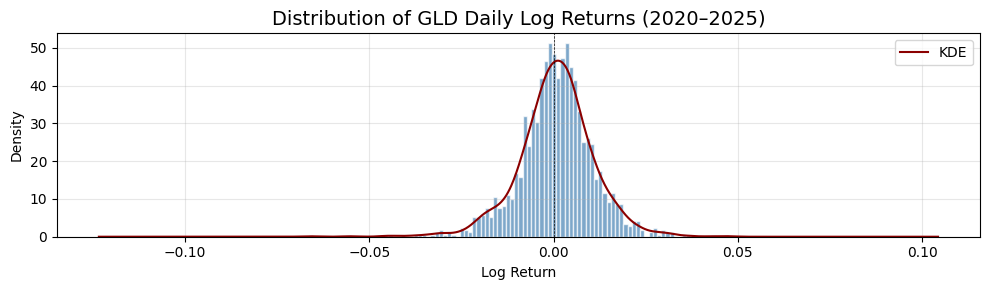

In [29]:
# Plot return distribution
ret = df.loc['2020':, 'GLD_LogRet']

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ret, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ret.plot.kde(ax=ax, color='darkred', linewidth=1.5, label='KDE')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Distribution of GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Descriptive statistics of GLD daily log returns
ret = df.loc['2020':, 'GLD_LogRet']

stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Skewness', 'Kurtosis (excess)',
                  'Min', '5th Percentile', '25th Percentile', '75th Percentile',
                  '95th Percentile', 'Max'],
    'Value': [f"{len(ret):,.0f}", f"{ret.mean():.6f}", f"{ret.median():.6f}", f"{ret.std():.6f}", f"{ret.skew():.4f}", f"{ret.kurtosis():.4f}",
              f"{ret.min():.6f}", f"{ret.quantile(0.05):.6f}", f"{ret.quantile(0.25):.6f}", f"{ret.quantile(0.75):.6f}", f"{ret.quantile(0.95):.6f}", f"{ret.max():.6f}"]})

stats.T

,0,1,2,3,4,5,6,7,8,9,10,11
Statistic,Count,Mean,Median,Std Dev,Skewness,Kurtosis (excess),Min,5th Percentile,25th Percentile,75th Percentile,95th Percentile,Max
Value,"1,507",0.000681,0.000858,0.010309,-0.4359,3.1915,-0.066427,-0.016459,-0.004661,0.006322,0.016720,0.047390


The descriptive statistics has  a mean of 0.069%, which is trending slightly positive, potentially creating class imbalance. With the skewness at -0.44, this illustrates drawdowns are larger than upward movements. Kurtosis is also suggesting the returns sereis have fat tails. <br>

The return distribution shows a concentration of near-zero observations that require a classification decision — either exclude them from the training dataset, or reclassify them. To select an appropriate threshold, we first examine how observations fall within various bands. If we set the threshold too low, it retains noise in the labels; too high reduces the training sample and the model's ability to generalize.

In [31]:
# Count observations within candidate different thresholds
ret = df.loc['2020':, 'GLD_LogRet']
total = len(ret)
std = ret.std()

thresholds = [0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.005]

rows = []
for t in thresholds:
    in_zone = ret.abs() < t
    n_drop = in_zone.sum()
    rows.append({
        'Threshold': f'±{t:.4f} ({t*100:.2f}%)',
        'Fraction of σ': f'{t / std:.2f}σ',
        'Observations Dropped': n_drop,
        '% of Total': f'{n_drop / total * 100:.1f}%',
        'Remaining': total - n_drop
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,Fraction of σ,Observations Dropped,% of Total,Remaining
0,±0.0005 (0.05%),0.05σ,68,4.5%,1439
1,±0.0010 (0.10%),0.10σ,152,10.1%,1355
2,±0.0015 (0.15%),0.15σ,209,13.9%,1298
3,±0.0020 (0.20%),0.19σ,293,19.4%,1214
4,±0.0025 (0.25%),0.24σ,356,23.6%,1151
5,±0.0030 (0.30%),0.29σ,420,27.9%,1087
6,±0.0050 (0.50%),0.49σ,678,45.0%,829


Based on the analysis above, small positive returns below +0.0020 (0.20%) are classified as non-positive (label = 0). This treats moves within approximately 0.19 standard deviations of zero as carrying no meaningful directional signal — they are statistically indistinguishable from noise and economically marginal. It also retains the full dataset for training while producing a stricter definition of a positive move. In production, a volatility-adaptive threshold scaled to rolling local standard deviation would better account for regime shifts; for this study, a fixed threshold is used for simplicity and reproducibility.

The target variable is defined as:

$$y_t = \begin{cases} 1, & \text{if } r_{t+1} > 0.0020 \\ 0, & \text{otherwise} \end{cases}$$

where: <br>
$r_{t+1} = \ln(P_{t+1}) - \ln(P_t)$ is the next-day log return of GLD. Standing at the close of day $t$ with all available information, the model predicts whether tomorrow's return will exceed the +0.20% threshold.

In [32]:
# Construct binary target variable - Label = 1 if log return exceeds +0.20%, else 0

# Forward one-day GLD log return: return from t to t+1
df['Forward_LogRet_1d'] = df['GLD_LogRet'].shift(-1)

# Remove final row because its future return is unknown
df = df[df['Forward_LogRet_1d'].notna()].copy()

# Binary target: 1 if next-day return exceeds +0.20%, else 0
df['Label'] = (df['Forward_LogRet_1d'] > 0.002).astype(int)

We examine the class distribution to check for imbalance, which may require adjustment during model training.

Class 0: 828 (55.0%)
Class 1: 678 (45.0%)


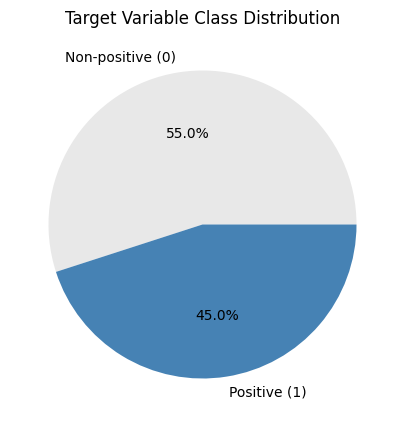

In [33]:
# Class balance
counts = df.loc['2020':, 'Label'].value_counts()
print(f"Class 0: {counts[0]} ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Class 1: {counts[1]} ({counts[1]/counts.sum()*100:.1f}%)")

df.loc['2020':, 'Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Non-positive (0)', 'Positive (1)'],
    colors=['#E8E8E8', 'steelblue'],
    figsize=(5, 5),
    title='Target Variable Class Distribution'
)
plt.ylabel('')
plt.show()

The class distribution is approximately balanced at 55/45, with a mild skew toward non-positive outcomes following the reclassification of near-zero returns. This moderate imbalance will be addressed using balanced sample weighting during model training.

b) Feature Engineering

The feature set is organized into four thematic categories, totaling approximately 47 engineered features derived from the 23 raw columns in the dataset. The categories reflect various information channels that drive gold price:

1. **Technical** (~20 features) — Price action, momentum, volatility, and volume patterns derived from GLD OHLCV data. These capture the dynamics of gold's own price process.

2. **Cross-Asset** (~9 features) — Relative performance and co-movement with related assets (silver, gold miners, equities, treasuries).

3. **Macro** (~11 features) — Interest rates, real yields, inflation expectations, credit conditions, the US dollar, oil, and volatility. These are the fundamental drivers of gold's role as a real asset, inflation hedge, and safe haven.

4. **Positioning** (~7 features) — CFTC Commitments of Traders data capturing speculator and commercial hedger positioning in gold futures. Extreme positioning has historically preceded trend reversals.

Rolling window lengths of 7, 14, 28, and 63 trading days correspond approximately to 1-week, 2-week, 1-month, and 1-quarter horizons.

### Category 1: Technical Features (~20 features from GLD OHLCV)

Technical features extract information from GLD's own price and volume history. The core building blocks are:

- **Rolling cumulative returns** over 7, 14, 28, and 63 days capture momentum at multiple horizons.
- **Rolling volatility** (standard deviation of daily log returns) measures the dispersion of returns at each horizon. Volatility clustering — visible in the time series plot above — means recent volatility is informative about near-term return distributions.
- **Bollinger %B** normalises the closing price's position within its Bollinger Band to a 0–1 scale: $\%B = (P - LB) / (UB - LB)$.
- **Intraday structure**: the open-to-close ratio for intraday direction, high-low range proxies intraday volatility, and the overnight gap captures information flow between Asia/ European/ US markets.
- **RSI (14-day)** measures momentum. Values > 70 suggest overbought < 30 suggests oversold.
- **Volume percentage changes** capture shifts in trading activity.
- **Lagged return** (1-day) allows the model to detect any residual autocorrelation in daily returns.

In [34]:
# ── Category 1: Technical Features (~20 from GLD OHLCV) ──

# 1. Rolling cumulative log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollRet_{w}d'] = df['GLD_LogRet'].rolling(w).sum()

# 2. Rolling volatility — std of daily log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollVol_{w}d'] = df['GLD_LogRet'].rolling(w).std()

# 3. Bollinger %B — normalised band position (2 features)
for w in [14, 28]:
    sma = df['GLD_Close'].rolling(w).mean()
    std = df['GLD_Close'].rolling(w).std()
    ub = sma + 2 * std
    lb = sma - 2 * std
    df[f'BB_PctB_{w}d'] = (df['GLD_Close'] - lb) / (ub - lb)

# 4. Volume percentage change (3 features)
for w in [7, 14, 28]:
    df[f'VolChg_{w}d'] = df['GLD_Volume'].pct_change(w)

# 5. Intraday structure (3 features)
df['OC'] = (df['GLD_Close'] - df['GLD_Open']) / df['GLD_Open']    # open-to-close body
df['HL'] = (df['GLD_High'] - df['GLD_Low']) / df['GLD_Close']     # intraday range
df['GAP'] = df['GLD_Open'] / df['GLD_Close'].shift(1) - 1         # overnight gap

# 6. Rolling mean of overnight gap (1 feature)
df['GAP_14d'] = df['GAP'].rolling(14).mean()

# 7. RSI — 14-day, simple moving average variant (1 feature)
_gain = df['GLD_LogRet'].clip(lower=0)
_loss = -df['GLD_LogRet'].clip(upper=0)
_avg_gain = _gain.rolling(14).mean()
_avg_loss = _loss.rolling(14).mean()
df['RSI_14d'] = 100 - (100 / (1 + _avg_gain / _avg_loss))

# 8. Lagged return (1 feature)
df['LagRet_1d'] = df['GLD_LogRet'].shift(1)

# Clean up temp variables
del _gain, _loss, _avg_gain, _avg_loss

# ── Verify ──
cat1_features = ['GLD_LogRet', 'RollRet_7d', 'RollRet_14d', 'RollRet_28d', 'RollRet_63d', 'RollVol_7d', 'RollVol_14d', 'RollVol_28d', 'RollVol_63d', 'BB_PctB_14d', 'BB_PctB_28d',
                 'VolChg_7d', 'VolChg_14d', 'VolChg_28d', 'OC', 'HL', 'GAP', 'GAP_14d', 'RSI_14d', 'LagRet_1d']

print(f"Category 1: {len(cat1_features)} features")
df[cat1_features].head()

Category 1: 20 features


,GLD_LogRet,RollRet_7d,RollRet_14d,RollRet_28d,RollRet_63d,RollVol_7d,RollVol_14d,RollVol_28d,RollVol_63d,BB_PctB_14d,BB_PctB_28d,VolChg_7d,VolChg_14d,VolChg_28d,OC,HL,GAP,GAP_14d,RSI_14d,LagRet_1d
Date,,,,,,,,,,,,,,,,,,,,
2019-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008220,0.011510,NaN,NaN,NaN,NaN
2019-06-04,0.000320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002162,0.006472,-0.001838,NaN,NaN,NaN
2019-06-05,0.002554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005627,0.009006,0.008230,NaN,NaN,0.000320
2019-06-06,0.003262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000397,0.005164,0.003666,NaN,NaN,0.002554
2019-06-07,0.005624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001577,0.007347,0.007229,NaN,NaN,0.003262


### Category 2: Cross-Asset Features (~9 features)

Gold's price dynamics are influenced by other related assets. These features capture relative valuation and co-movement across the precious metals complex, equities, and fixed income.

- **Cross-asset log returns** (GDX, SLV, SPY, TLT) provide same-day directional signals from related markets.
- **Gold/Silver ratio** (GLD/SLV) is a widely followed relative valuation metric — a rising ratio historically signals risk aversion and safe-haven demand for gold over silver.
- **Miner leverage ratio** (GDX/GLD) captures whether miners are outperforming or underperforming the metal itself, often provides indicative signals and sentiments.
- **Rolling correlations** (GLD vs SPY, GLD vs TLT over 28 days) measure the time-varying relationship between gold and broader markets. Gold's correlation with equities is regime-dependent — negative during crises, near-zero or positive during risk-on environments.
- **Relative performance** (GLD vs SPY 28-day cumulative return spread) captures medium-term rotation between gold and equities.

In [35]:
# ── Category 2: Cross-Asset Features (~9 features) ──

# 1. Cross-asset daily log returns (4 features)
for ticker in ['GDX', 'SLV', 'SPY', 'TLT']:
    df[f'{ticker}_LogRet'] = np.log(df[f'{ticker}_Close']).diff()

# 2. Gold/Silver ratio (1 feature)
df['GLD_SLV_Ratio'] = df['GLD_Close'] / df['SLV_Close']

# 3. Miner leverage ratio (1 feature)
df['GDX_GLD_Ratio'] = df['GDX_Close'] / df['GLD_Close']

# 4. Rolling 28-day correlations (2 features)
df['Corr_GLD_SPY_28d'] = df['GLD_LogRet'].rolling(28).corr(df['SPY_LogRet'])
df['Corr_GLD_TLT_28d'] = df['GLD_LogRet'].rolling(28).corr(df['TLT_LogRet'])

# 5. Relative performance — GLD vs SPY cumulative return spread over 28 days (1 feature)
df['RelPerf_GLD_SPY_28d'] = (df['GLD_LogRet'].rolling(28).sum() - df['SPY_LogRet'].rolling(28).sum())

cat2_features = ['GDX_LogRet', 'SLV_LogRet', 'SPY_LogRet', 'TLT_LogRet', 'GLD_SLV_Ratio', 'GDX_GLD_Ratio', 'Corr_GLD_SPY_28d', 'Corr_GLD_TLT_28d', 'RelPerf_GLD_SPY_28d']

### Category 3: Macro Features (~11 features from FRED)

Macroeconomic variables are the fundamental drivers to gold pricing as gold is a real asset, inflation hedge and a safe-haven asset.

- **Real yield level** (DFII10) Higher real yields increase the opportunity cost of holding gold, as it is a non-yielding asset
- **Rate changes** (daily differences of DGS10, DFII10, DFF) capture the direction of monetary policy and rate expectations. Gold tends to rally when rates are falling.
- **Credit spread** (DBAA − DGS10) measures corporate credit stress. Widening spreads signal risk aversion, potentially supporting gold price.
- **Yield curve** (T10Y2Y) captures the term structure slope — an inverting curve signals recession expectations, historically supportive for gold.
- **Breakeven inflation** (T10YIE) reflects market-implied inflation expectations. Rising breakevens support gold's role as an inflation hedge.
- **VIX level and 14-day rolling mean** capture equity market fear. Elevated VIX tends to coincide with flows to safe-haven assets.
- **Oil log return** (DCOILWTICO) captures commodity complex momentum
- **USD log return** (DTWEXBGS) captures the inverse relationship between gold and the dollar — gold is mostly priced in USD, dollar strength may impact gold price.

In [36]:
# ── Category 3: Macro Features (~11 features from FRED) ──

# 1. Real yield level (1 feature)
df['RealYield'] = df['DFII10']

# 2. Rate changes — daily differences (3 features)
df['DGS10_Chg'] = df['DGS10'].diff()
df['DFII10_Chg'] = df['DFII10'].diff()
df['DFF_Chg'] = df['DFF'].diff()

# 3. Credit spread (1 feature)
df['CreditSpread'] = df['DBAA'] - df['DGS10']

# 4. Yield curve level (1 feature)
df['YieldCurve'] = df['T10Y2Y']

# 5. Breakeven inflation level (1 feature)
df['BreakevenInfl'] = df['T10YIE']

# 6. VIX — level and 14-day rolling mean (2 features)
df['VIX'] = df['VIXCLS']
df['VIX_14d'] = df['VIXCLS'].rolling(14).mean()

# 7. Oil log return (1 feature)
df['Oil_LogRet'] = np.log(df['DCOILWTICO']).diff()

# 8. USD log return (1 feature)
df['USD_LogRet'] = np.log(df['DTWEXBGS']).diff()

cat3_features = ['RealYield', 'DGS10_Chg', 'DFII10_Chg', 'DFF_Chg', 'CreditSpread', 'YieldCurve', 'BreakevenInfl', 'VIX', 'VIX_14d', 'Oil_LogRet', 'USD_LogRet']

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Category 4: Positioning Features (~7 features from CFTC COT)

The CFTC Commitments of Traders report provides weekly snapshots of futures positioning by trader category. In gold futures, two groups dominate: non-commercial traders (speculators, largely trend-followers) and commercial traders (producers and consumers hedging physical exposure). Extreme positioning — particularly crowded speculator longs — has historically preceded trend exhaustion and reversals.

- **Speculator net long** and **commercial net short** capture the directional stance of each group in absolute terms.
- **Weekly deltas** of each measure the rate of change in positioning — accelerating or decelerating conviction.
- **Open interest** reflects the total size of the market, OI direction can signal captial entering or liquidating.
- **Spec net long as % of OI** normalises speculator positioning against market size, making it comparable across different OI regimes.
- **Spec long/short ratio** provides an alternative normalisation — how  speculator positioning is within their own books.

Note: COT data is reported weekly (Tuesday snapshot, published Friday) with a 4-business-day lag applied during data collection. Values are forward-filled to daily frequency, so these features update once per week.

In [37]:
# ── Category 4: Positioning Features (~7 features from CFTC COT) ──

# 1. Speculator net long (1 feature)
df['Spec_NetLong'] = df['COT_Spec_Long'] - df['COT_Spec_Short']

# 2. Commercial net short (1 feature)
df['Comm_NetShort'] = df['COT_Comm_Short'] - df['COT_Comm_Long']

# 3. Open interest level (1 feature)
df['COT_OI_Level'] = df['COT_OI']

# 4. Weekly delta of speculator net long (1 feature)
df['Spec_NetLong_Delta'] = df['Spec_NetLong'].diff(5)

# 5. Weekly delta of commercial net short (1 feature)
df['Comm_NetShort_Delta'] = df['Comm_NetShort'].diff(5)

# 6. Spec net long as % of open interest (1 feature)
df['Spec_NetLong_PctOI'] = df['Spec_NetLong'] / df['COT_OI']

# 7. Spec long/short ratio (1 feature)
df['Spec_LS_Ratio'] = df['COT_Spec_Long'] / df['COT_Spec_Short']

# ── Verify ──
cat4_features = ['Spec_NetLong', 'Comm_NetShort', 'COT_OI_Level', 'Spec_NetLong_Delta', 'Comm_NetShort_Delta', 'Spec_NetLong_PctOI', 'Spec_LS_Ratio']

In [38]:
# ── Assemble full feature matrix ──
all_features = cat1_features + cat2_features + cat3_features + cat4_features

print(f"Total engineered features: {len(all_features)}")

# Build feature matrix + label
features_df = df[all_features + ['Label']].dropna()

print(f"First usable row: {features_df.index[0]}")
print(f"Last row: {features_df.index[-1]}")
print(f"Total usable observations: {len(features_df)}")
print(f"Label distribution:\n{features_df['Label'].value_counts()}")

# save to data folder
features_df.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv')

Total engineered features: 47
First usable row: 2019-12-02 00:00:00
Last row: 2025-12-29 00:00:00
Total usable observations: 1525
Label distribution:
Label
0    838
1    687
Name: count, dtype: int64


### **B. Feature Selection Using the Funnelling Approach**

In [39]:
# Load engineered features
df_feat = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv', index_col=0, parse_dates=True)

# Separate features and label
y = df_feat['Label']
X = df_feat.drop('Label', axis=1)

print(f"Feature matrix: {X.shape[0]} observations x {X.shape[1]} features")
print(f"Class distribution:{y.value_counts()}")

Feature matrix: 1525 observations x 47 features
Class distribution:Label
0    838
1    687
Name: count, dtype: int64


### **a) Explain the feature selection process using the three categories of feature selection methods, step by step.**

Feature Selection Process

The feature-selection process was designed as a funnel, combining filter, wrapper, and embedded methods to evaluate broad sets of features and engineered features, and systematically reduced to a smaller core. <br>

Before applying the funneling process, the data is first split chronologically into training and testing sets. This is important as feature selection is part of the model-building process, if funneling methods are scored using the full dataset, information from test period may indirectly influence what features are retained, creating selection leakage. The current designed process avoids redundancy, overfitting, and look-ahead bias.

In this project, as we are working with 47 features, we will
sequentially conduct filtering methods, followed by wrapper methods and embedded methods.This order allows us to use computationally efficient methods to handle the broadest cuts,while allowing more model-aware methods to work on the remaining focused set.

**Filtering methods** – evaluate features using statistical properties of the data, aims
to screen out features with poor standalone data quality or excessive redundancy. Common
techniques include correlation analysis, chi-square tests, ANOVA, variance thresholds and
information gain. Since many financial variables are economically related, filtering will
help remove duplicate information and in here we will apply correlation analysis to remove
features with high absolute correlation with a defined threshold at |ρ| > 0.85.

**Wrapper methods** – evaluate features by training a model and measuring how each feature
contributes to the predictions. Common techniques include forward selection, backward
elimination, Boruta and SHAP. These techniques can be more model-specific and more
powerful than filtering as they capture feature interactions. In here, we apply SHAP
(SHapley Additive exPlanations) to compute each feature's marginal contribution to
individual predictions, ranked by mean absolute SHAP value. Features contributing below
the median are removed.

**Embedded methods** – is a model-aware method to rate each feature's importance measured
by how much it contributes to reducing the loss function across all splits under the
selected model. Common techniques include Lasso, Ridge, ElasticNet and tree-based
importance from Random Forest, XGBoost or LightGBM. In here, we are using XGBoost's
gain-based feature importance, which measures the average reduction in log-loss
contributed by each feature. Features whose gain falls below 75% of the maximum are
removed.

The planned funnelling sequence is summarised below:

| Stage | Category | Technique | Selection Criterion |
|-------|----------|-----------|---------------------|
| 1 | Filter | Pairwise Correlation | Drop features with p > 0.85 |
| 2 | Wrapper | SHAP | Drop features below median mean |SHAP| |
| 3 | Embedded | XGBoost Gain | Drop features below 75% of max gain |

### **Design Train/ Test Split**

The dataset is split chronologically using an 80/20 train-test split, with 1 trading day purge gap in between to preserve the time-series ordering and avoid overlap, selection leakage and look-ahead bias.
The training sample contains 1,202 observations from 2020-01-02 to 2024-10-14, while the test sample contains 301 observations from 2024-10-16 to 2025-12-29. The training set is mildly imbalanced, with class 0 representing 56.3% of observations and class 1 representing 43.7%. The test set is more balanced, with class 1 representing 50.2% and class 0 representing 49.8%. Since the imbalance is not severe, no resampling method is applied at this stage. Instead, model performance is evaluated using ROC-AUC, confusion matrix and classification report to assess whether the trained model generalizes to unseen future data.

In [40]:
# Load engineered full feature set
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv', index_col=0, parse_dates=True)

# Filter to study period: 2020-01-01 to 2025-12-31
data = data.loc['2020':'2025'].copy()

In [44]:
# Chronological split with 1-day purge gap
split = int(len(data) * 0.8)
purge_gap = 1

train_data = data.iloc[:split - purge_gap].copy()
test_data  = data.iloc[split:].copy()

# Optional: inspect purged row
purged_data = data.iloc[split - purge_gap:split].copy()

# Separate features and label
leakage_cols = ['Label', 'Forward_LogRet_1d']

X_train = train_data.drop(columns=[col for col in leakage_cols if col in train_data.columns])
y_train = train_data['Label']

X_test = test_data.drop(columns=[col for col in leakage_cols if col in test_data.columns])
y_test = test_data['Label']

print(f"Training set: {len(X_train)} rows ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Purged gap:   {len(purged_data)} row ({purged_data.index.min().date()} to {purged_data.index.max().date()})")
print(f"Test set:     {len(X_test)} rows ({X_test.index.min().date()} to {X_test.index.max().date()})")
print(f"Features:     {X_train.shape[1]}")

print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 1202 rows (2020-01-02 to 2024-10-14)
Purged gap:   1 row (2024-10-15 to 2024-10-15)
Test set:     301 rows (2024-10-16 to 2025-12-29)
Features:     47
Train class balance:
Label
0    0.563
1    0.437
Name: proportion, dtype: float64
Test class balance:
Label
1    0.502
0    0.498
Name: proportion, dtype: float64


### **(b) Justify the selection of features retained at each step.**

**i) Filtering Method - Pairwise Correlation** <br>

At the filter stage, pairwise absolute correlation was computed using the training sample only. Features with absolute correlation above 0.85 were treated as highly redundant, and one feature from each highly correlated pair was removed. This reduced the feature set from 47 to 39 features. The purpose of this stage is not to identify the most predictive variables, but to remove duplicated information before applying more model-aware wrapper and embedded methods.

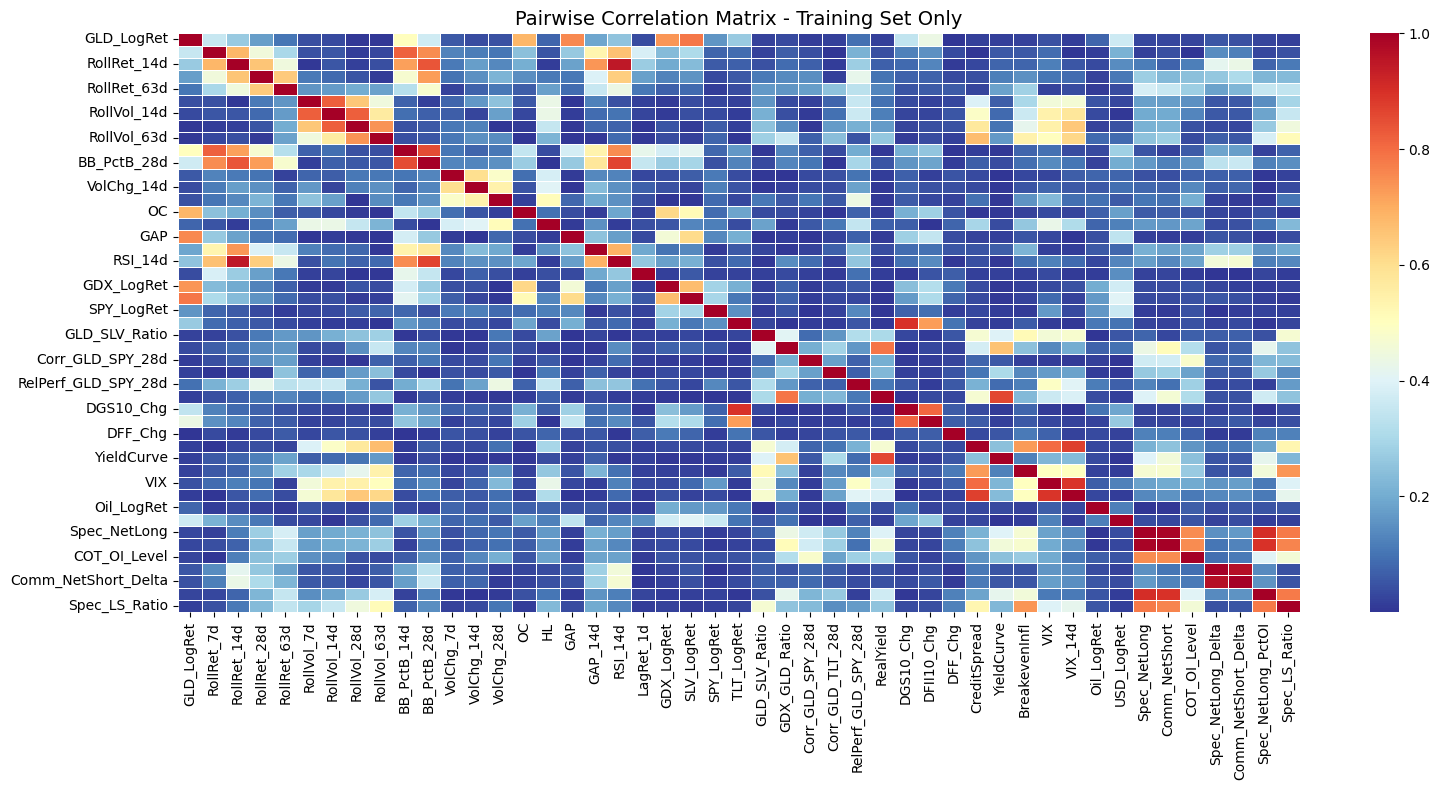

In [45]:
# Compute absolute correlation matrix on training features only
corr_matrix = X_train.corr().abs()

# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(corr_matrix, cmap='RdYlBu_r', center=0.5, ax=ax, linewidths=0.5)
ax.set_title('Pairwise Correlation Matrix - Training Set Only', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Correlation filter fitted on training set only
threshold = 0.85

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

X_train_corr = X_train.drop(columns=to_drop_corr)
X_test_corr  = X_test.drop(columns=to_drop_corr)

print(f"Original features: {X_train.shape[1]}")
print(f"Dropped due to |correlation| > {threshold}: {len(to_drop_corr)}")
print(f"Remaining features after correlation filter: {X_train_corr.shape[1]}")
print("Dropped features:")
print(to_drop_corr)

Original features: 47
Dropped due to |correlation| > 0.85: 8
Remaining features after correlation filter: 39
Dropped features:
['BB_PctB_28d', 'RSI_14d', 'DGS10_Chg', 'YieldCurve', 'VIX_14d', 'Comm_NetShort', 'Comm_NetShort_Delta', 'Spec_NetLong_PctOI']


The correlation filter removed 8 features at the |ρ| > 0.85 threshold, reducing the set from 47 to 39. All dropped features were mechanically or economically redundant with a retained counterpart: RSI is derived from cumulative returns, VIX_14d is a smoothed version of VIX, DGS10_Chg and TLT_LogRet both measure bond market moves, and the three CFTC positioning pairs reflect that speculator and commercial positions are mirror images by construction. No unique informational content was lost.

**ii) Wrapper Method - SHAP**

The wrapper stage uses a SHAP-guided XGBoost procedure. SHAP is primarily an explainability method, but in this project it is used as a model-dependent feature-ranking mechanism inside a wrapper-style selection process. Mean absolute SHAP values are used to rank the post-correlation features, and features above the median mean-|SHAP| value are retained.

In [48]:
# Train XGBoost on the post-correlation Training feature set only
# Default/simple hyperparameters are used intentionally — tuning is deferred to Part C
sample_weights_shap = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_shap = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    verbosity=0,
    eval_metric='logloss',
    random_state=42
)

xgb_shap.fit(X_train_corr, y_train, sample_weight=sample_weights_shap)

# Compute SHAP values on training data only
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_train_corr)

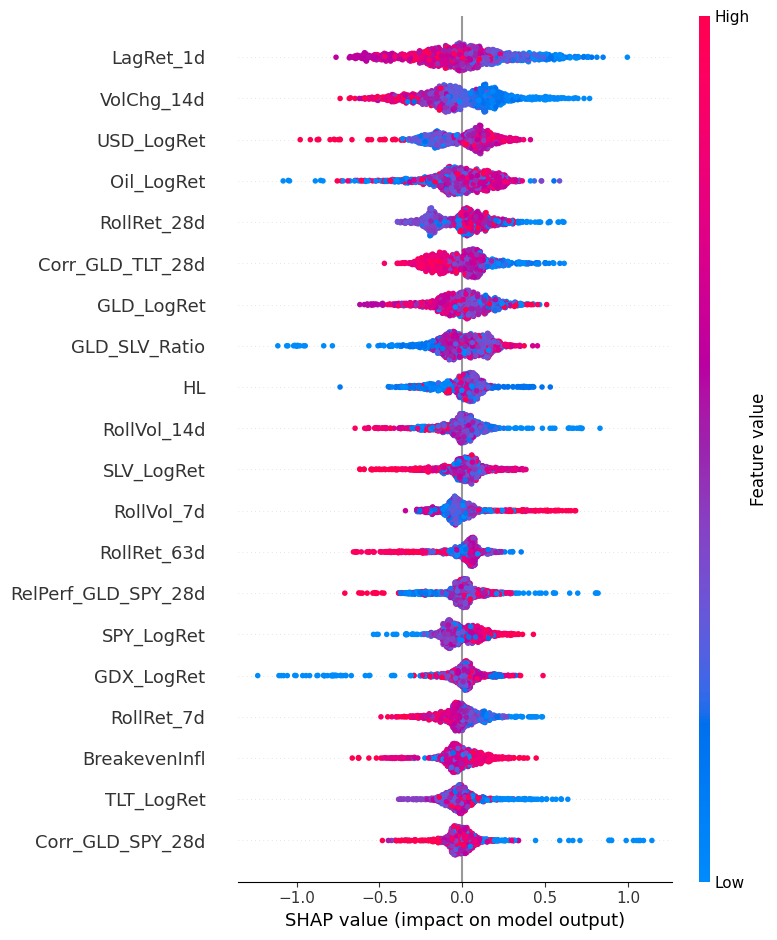

In [49]:
# Beeswarm plot — direction + magnitude of each feature's impact
shap.summary_plot(shap_values, X_train_corr, show=True)

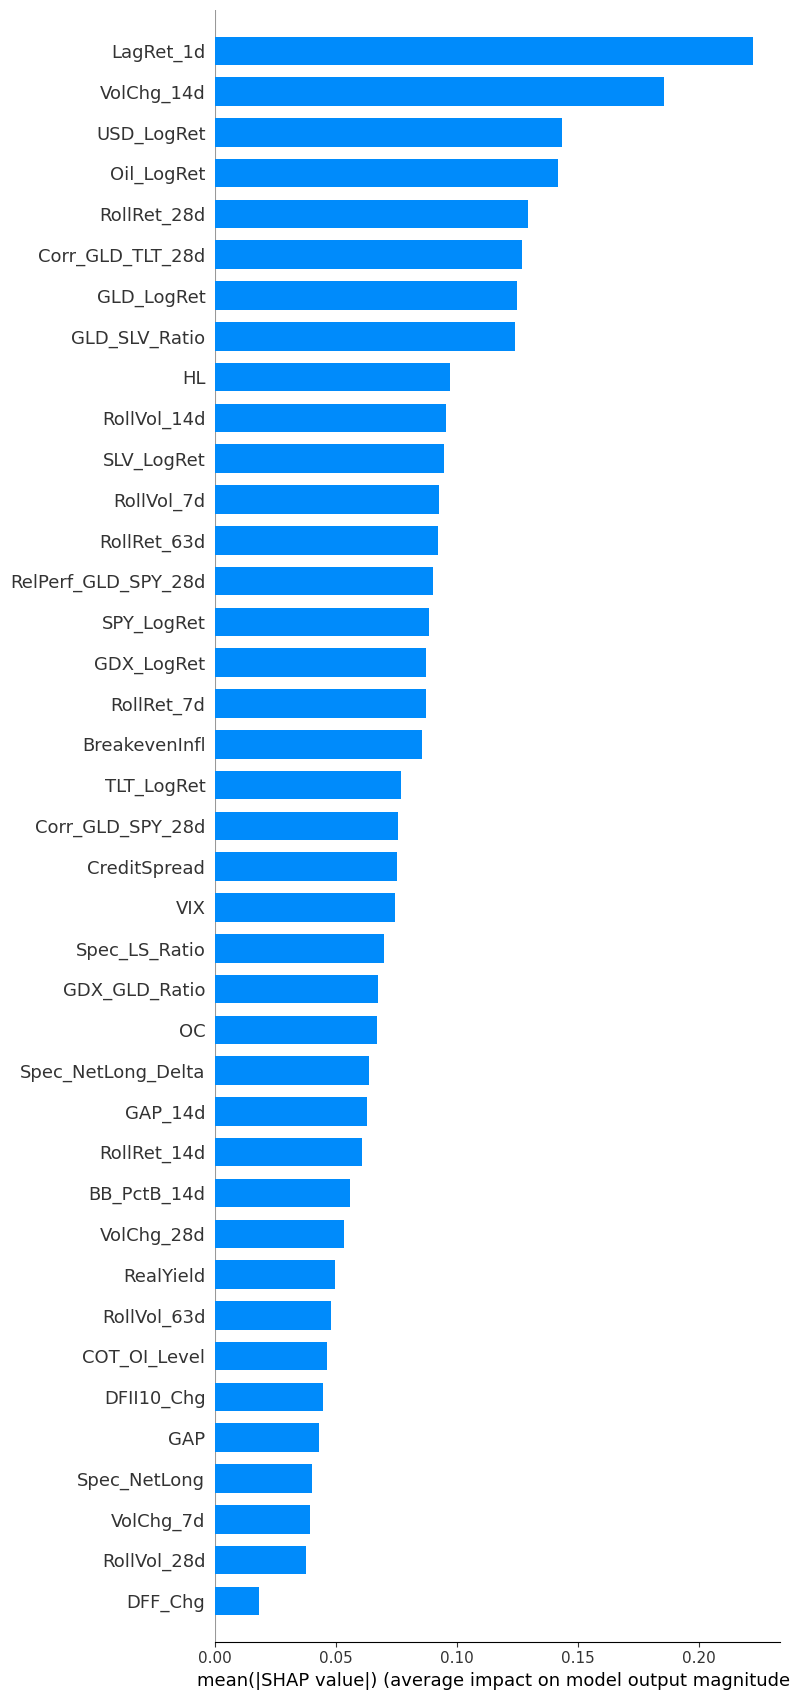

In [50]:
# Bar plot — ranks features by mean absolute SHAP value
shap.summary_plot(shap_values, X_train_corr, plot_type='bar', max_display=40, show=True)

In [51]:
# Compute mean absolute SHAP values per feature
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = (
    pd.DataFrame({
        'Feature': X_train_corr.columns,
        'Mean_SHAP': mean_shap
    })
    .sort_values('Mean_SHAP', ascending=False)
    .reset_index(drop=True)
)
shap_df

,Feature,Mean_SHAP
0,LagRet_1d,0.222427
1,VolChg_14d,0.185574
2,USD_LogRet,0.143304
3,Oil_LogRet,0.141737
4,RollRet_28d,0.129218
5,Corr_GLD_TLT_28d,0.126777
6,GLD_LogRet,0.124693
7,GLD_SLV_Ratio,0.124004
8,HL,0.096941
9,RollVol_14d,0.095342


In [52]:
# Retain features with mean |SHAP| above median
shap_threshold = shap_df['Mean_SHAP'].median()

retained_shap = shap_df[shap_df['Mean_SHAP'] >= shap_threshold]['Feature'].tolist()
dropped_shap  = shap_df[shap_df['Mean_SHAP'] < shap_threshold]['Feature'].tolist()

print(f"\nSHAP threshold (median): {shap_threshold:.6f}")
print(f"Features retained ({len(retained_shap)}): {retained_shap}")
print(f"Features dropped  ({len(dropped_shap)}): {dropped_shap}")

# Apply selected SHAP features to both train and test
X_train_stage2 = X_train_corr[retained_shap].copy()
X_test_stage2  = X_test_corr[retained_shap].copy()

print(f"\nFeatures remaining after Stage 2 (Wrapper): {X_train_stage2.shape[1]}")


SHAP threshold (median): 0.075684
Features retained (20): ['LagRet_1d', 'VolChg_14d', 'USD_LogRet', 'Oil_LogRet', 'RollRet_28d', 'Corr_GLD_TLT_28d', 'GLD_LogRet', 'GLD_SLV_Ratio', 'HL', 'RollVol_14d', 'SLV_LogRet', 'RollVol_7d', 'RollRet_63d', 'RelPerf_GLD_SPY_28d', 'SPY_LogRet', 'GDX_LogRet', 'RollRet_7d', 'BreakevenInfl', 'TLT_LogRet', 'Corr_GLD_SPY_28d']
Features dropped  (19): ['CreditSpread', 'VIX', 'Spec_LS_Ratio', 'GDX_GLD_Ratio', 'OC', 'Spec_NetLong_Delta', 'GAP_14d', 'RollRet_14d', 'BB_PctB_14d', 'VolChg_28d', 'RealYield', 'RollVol_63d', 'COT_OI_Level', 'DFII10_Chg', 'GAP', 'Spec_NetLong', 'VolChg_7d', 'RollVol_28d', 'DFF_Chg']

Features remaining after Stage 2 (Wrapper): 20


The SHAP stage reduced the post-correlation feature set from 39 to 20 features. The retained variables are economically interpretable and span several groups: recent GLD return dynamics, volume and volatility conditions, USD and oil returns, silver and gold-miner proxies, bond-market proxies, inflation expectations, and equity/gold relative-performance measures. This suggests that the model is not relying only on GLD technical indicators, but is also using cross-asset information relevant to gold.

Features removed at this stage were not necessarily irrelevant, they just had below-median mean absolute SHAP contribution within the XGBoost model fitted on the training sample. The selected 20-feature subset is therefore used as the input to the next embedded feature-selection stage.


**iii) Embedded Method - XGBoost Gain**

For the embedded feature-selection stage, XGBoost gain-based importance is used. In XGBoost, gain measures the average improvement in the model objective produced by splits using each feature. Features with higher gain therefore contribute more directly to reducing classification loss within the boosted-tree model.

This stage is consistent with the final modelling approach, gain-based importance provides a final model-aware screen using the training sample only. The selected feature subset is then applied unchanged to the test sample to preserve the out-of-sample evaluation.

In [53]:
# Train XGBoost on the post-SHAP TRAINING feature set only
# Default/simple hyperparameters are used intentionally — tuning is deferred to Part C
sample_weights_s3 = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_selector = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    verbosity=0,
    eval_metric='logloss',
    random_state=42
)

xgb_selector.fit(X_train_stage2, y_train, sample_weight=sample_weights_s3)

# Extract gain-based feature importance
importance = xgb_selector.get_booster().get_score(importance_type='gain')

imp_df = pd.DataFrame({'Feature': X_train_stage2.columns, 'Gain': [importance.get(f, 0.0) for f in X_train_stage2.columns]}).sort_values('Gain', ascending=False).reset_index(drop=True)

imp_df

,Feature,Gain
0,VolChg_14d,2.879529
1,Corr_GLD_SPY_28d,2.790032
2,Oil_LogRet,2.788151
3,LagRet_1d,2.613949
4,GLD_SLV_Ratio,2.591156
5,Corr_GLD_TLT_28d,2.568332
6,RollVol_7d,2.505145
7,RollRet_7d,2.470284
8,SPY_LogRet,2.452404
9,RollVol_14d,2.438814


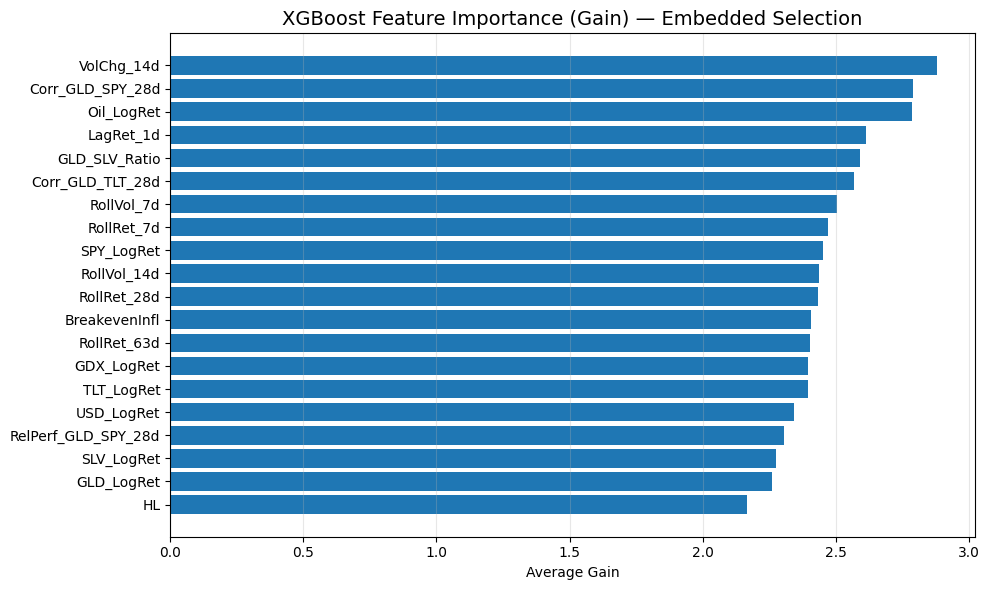

In [54]:
# Plot gain importance
imp_plot = imp_df.sort_values('Gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(imp_plot) * 0.3)))
ax.barh(imp_plot['Feature'], imp_plot['Gain'])
ax.set_xlabel('Average Gain')
ax.set_title('XGBoost Feature Importance (Gain) — Embedded Selection', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [55]:
# Cumulative gain selection
# Retain features that jointly explain 90% of total gain,
# with a minimum number of features to avoid over-pruning.

imp_df['Gain_Share'] = imp_df['Gain'] / imp_df['Gain'].sum()
imp_df['Cum_Gain_Share'] = imp_df['Gain_Share'].cumsum()

cum_gain_cutoff = 0.90
min_features = 10

retained_embedded = imp_df[
    imp_df['Cum_Gain_Share'] <= cum_gain_cutoff
]['Feature'].tolist()

# Ensure at least min_features are retained
top_min_features = imp_df.head(min_features)['Feature'].tolist()
retained_embedded = list(dict.fromkeys(retained_embedded + top_min_features))

dropped_embedded = [
    f for f in X_train_stage2.columns
    if f not in retained_embedded
]

print(f"\nCumulative gain cutoff: {cum_gain_cutoff:.0%}")
print(f"Minimum retained features: {min_features}")
print(f"Features retained ({len(retained_embedded)}): {retained_embedded}")
print(f"Features dropped  ({len(dropped_embedded)}): {dropped_embedded}")

# Apply selected features to both train and test
X_train_final = X_train_stage2[retained_embedded].copy()
X_test_final  = X_test_stage2[retained_embedded].copy()

print(f"\n=== Final feature set: {X_train_final.shape[1]} features ===")
print(f"Selected: {list(X_train_final.columns)}")


Cumulative gain cutoff: 90%
Minimum retained features: 10
Features retained (17): ['VolChg_14d', 'Corr_GLD_SPY_28d', 'Oil_LogRet', 'LagRet_1d', 'GLD_SLV_Ratio', 'Corr_GLD_TLT_28d', 'RollVol_7d', 'RollRet_7d', 'SPY_LogRet', 'RollVol_14d', 'RollRet_28d', 'BreakevenInfl', 'RollRet_63d', 'GDX_LogRet', 'TLT_LogRet', 'USD_LogRet', 'RelPerf_GLD_SPY_28d']
Features dropped  (3): ['GLD_LogRet', 'HL', 'SLV_LogRet']

=== Final feature set: 17 features ===
Selected: ['VolChg_14d', 'Corr_GLD_SPY_28d', 'Oil_LogRet', 'LagRet_1d', 'GLD_SLV_Ratio', 'Corr_GLD_TLT_28d', 'RollVol_7d', 'RollRet_7d', 'SPY_LogRet', 'RollVol_14d', 'RollRet_28d', 'BreakevenInfl', 'RollRet_63d', 'GDX_LogRet', 'TLT_LogRet', 'USD_LogRet', 'RelPerf_GLD_SPY_28d']


The embedded XGBoost gain stage reduced the SHAP-selected feature set from 20 to 17 features using a 90% cumulative gain threshold. Gain values were relatively evenly distributed across the 20 SHAP-selected variables, indicating that the model did not rely on a small number of dominant predictors. For this reason, a cumulative-gain threshold was preferred to a fixed percentage-of-maximum-gain cutoff, which could be unstable or overly arbitrary. The final 17-feature set remains sufficiently broad, covering GLD return dynamics, volatility, USD, oil, inflation, bond-market, equity-market, and cross-asset gold-related information.

**(c) Provide the final list of selected features**

In [57]:
# Final selected feature list
selected_features = list(X_train_final.columns)

final_df = pd.DataFrame({'Feature': selected_features})
final_df

,Feature
0,VolChg_14d
1,Corr_GLD_SPY_28d
2,Oil_LogRet
3,LagRet_1d
4,GLD_SLV_Ratio
5,Corr_GLD_TLT_28d
6,RollVol_7d
7,RollRet_7d
8,SPY_LogRet
9,RollVol_14d


In [58]:
# Save selected feature list
final_df.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/final_selected_features.csv', index=False)

# Save training and test datasets separately for Part C
train_funnelled = X_train_final.copy()
train_funnelled['Label'] = y_train

test_funnelled = X_test_final.copy()
test_funnelled['Label'] = y_test

train_funnelled.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled_train.csv')

test_funnelled.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled_test.csv')

# Save a combined file with split labels
features_funnelled = pd.concat([
    train_funnelled.assign(Split='train'),
    test_funnelled.assign(Split='test')
])

features_funnelled.to_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled.csv')

print(f"Saved {len(selected_features)} selected features + label.")
print(f"Training file: {train_funnelled.shape}")
print(f"Test file:     {test_funnelled.shape}")

Saved 17 selected features + label.
Training file: (1202, 18)
Test file:     (301, 18)


The funnelling process reduced the original 47 engineered features to 17 features through three successive stages. All feature-selection decisions were fitted using the training sample only, and the resulting feature subset was then applied unchanged to the test sample.

| Stage | Category | Technique | Input | Retained |
|-------|----------|-----------|-------|----------|
| 1 | Filter | Pairwise Correlation, \|ρ\| > 0.85 | 47 | 39 |
| 2 | Wrapper-style | SHAP-guided XGBoost ranking, above-median mean \|SHAP\| | 39 | 20 |
| 3 | Embedded | XGBoost gain, 90% cumulative gain threshold | 20 | 17 |


<br>The final feature set remains sufficiently broad and economically interpretable. It retains variables across GLD return dynamics, volatility and activity, USD and rates, inflation expectations, oil, equity-market relationships, and cross-asset gold-related information. <br><br>

| # | Feature | Category | Description |
|---|---------|----------|-------------|
| 1 | VolChg_14d | Technical / Activity | 14-day percentage change in GLD volume |
| 2 | Corr_GLD_SPY_28d | Cross-Asset | 28-day rolling correlation between GLD and SPY |
| 3 | Oil_LogRet | Macro / Commodity | Daily log return of WTI crude oil |
| 4 | LagRet_1d | Technical | One-day lagged GLD return |
| 5 | GLD_SLV_Ratio | Cross-Asset / Precious Metals | Gold-to-silver price ratio |
| 6 | Corr_GLD_TLT_28d | Cross-Asset / Rates | 28-day rolling correlation between GLD and TLT |
| 7 | RollVol_7d | Technical / Volatility | 7-day rolling volatility of GLD returns |
| 8 | RollRet_7d | Technical | 7-day rolling cumulative GLD return |
| 9 | SPY_LogRet | Cross-Asset / Equity Risk | Daily log return of SPY |
| 10 | RollVol_14d | Technical / Volatility | 14-day rolling volatility of GLD returns |
| 11 | RollRet_28d | Technical | 28-day rolling cumulative GLD return |
| 12 | BreakevenInfl | Macro / Inflation | Market-implied inflation expectation proxy |
| 13 | RollRet_63d | Technical | 63-day rolling cumulative GLD return |
| 14 | GDX_LogRet | Cross-Asset / Gold Miners | Daily log return of GDX |
| 15 | TLT_LogRet | Cross-Asset / Rates | Daily log return of TLT |
| 16 | USD_LogRet | Macro / FX | Daily log return of the USD index proxy |
| 17 | RelPerf_GLD_SPY_28d | Cross-Asset / Relative Performance | 28-day GLD versus SPY relative performance |

<p><br>
The embedded gain values were relatively evenly distributed, suggesting that the XGBoost selector did not rely on a single dominant predictor. For this reason, a cumulative-gain threshold was preferred to a fixed percentage-of-maximum-gain cutoff. The final 17-feature set provides a balanced compromise between dimensionality reduction and preserving diverse economic information for the modelling stage.</p>

### **V) Modelling**

## **C. Model Building, Tuning and Evaluation**

### **(a) Build a model to predict positive market moves (uptrend) using the feature subset derived above.**

We begin by training an XGBoost classifier with designed train/test datasets, the 17 final features, on default hyperparameters to establish a performance baseline. This baseline model will serve as the benchmark against other hyperparameter-tuned models in subsequent steps.

In [121]:
# XGBoost
from xgboost import XGBClassifier, plot_importance, to_graphviz

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

# Metrics
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             roc_auc_score, f1_score, precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay, confusion_matrix, classification_report)

a) load data

In [122]:
# Load funnelled train/test datasets created in Section B
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled_train.csv', index_col=0 ,parse_dates=True)

test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_funnelled_test.csv', index_col=0, parse_dates=True)

# Separate features and labels
X_train = train_data.drop(columns=['Label'])
y_train = train_data['Label'].astype(int)

X_test = test_data.drop(columns=['Label'])
y_test = test_data['Label'].astype(int)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"Training period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test period:     {X_test.index.min().date()} to {X_test.index.max().date()}")

Training set: 1202 rows, 17 features
Test set:     301 rows, 17 features
Training period: 2020-01-02 to 2024-10-14
Test period:     2024-10-16 to 2025-12-29


b) Fit Baseline Model

In [123]:
# Balanced sample weights based on training labels only
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Baseline XGBoost model
base_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

base_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [124]:
# Training performance
y_train_pred = base_model.predict(X_train)
y_train_proba = base_model.predict_proba(X_train)[:, 1]

print("=== Training Performance ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_train, y_train_proba):.4f}")

=== Training Performance ===
Accuracy:          0.8644
Balanced Accuracy: 0.8651
ROC-AUC:           0.9425


In [125]:
# Test performance
y_test_pred = base_model.predict(X_test)
y_test_proba = base_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_test_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


=== Test Performance ===
Accuracy:          0.5050
Balanced Accuracy: 0.5051
ROC-AUC:           0.4849

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.55      0.53       150
           1       0.51      0.46      0.48       151

    accuracy                           0.50       301
   macro avg       0.51      0.51      0.50       301
weighted avg       0.51      0.50      0.50       301



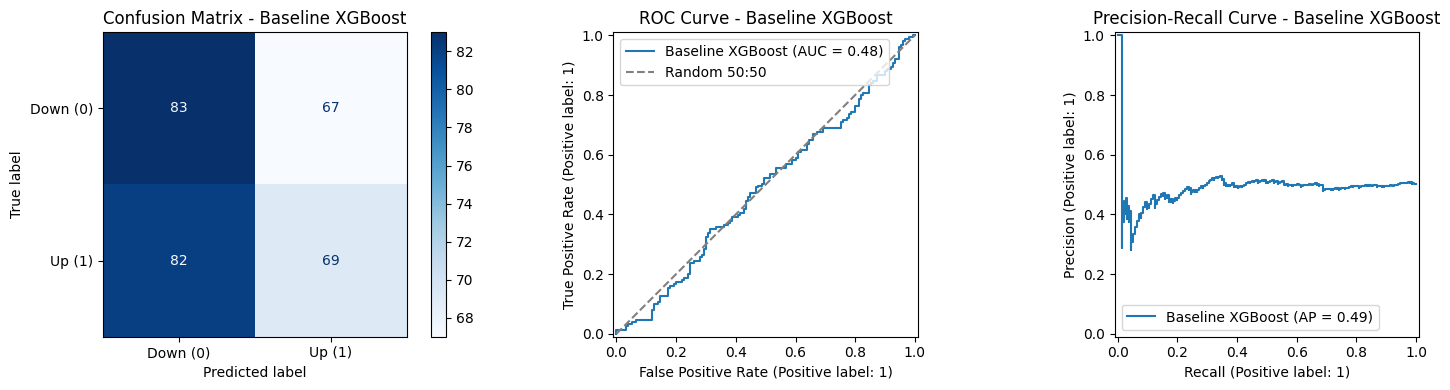

=== Baseline Test Classification Report ===
              precision    recall  f1-score   support

    Down (0)       0.50      0.55      0.53       150
      Up (1)       0.51      0.46      0.48       151

    accuracy                           0.50       301
   macro avg       0.51      0.51      0.50       301
weighted avg       0.51      0.50      0.50       301



In [126]:
# Baseline model diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    display_labels=['Down (0)', 'Up (1)'],
    cmap=plt.cm.Blues,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Baseline XGBoost')

# ROC Curve
RocCurveDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name='Baseline XGBoost',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random 50:50')
axes[1].set_title('ROC Curve - Baseline XGBoost')
axes[1].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name='Baseline XGBoost',
    ax=axes[2]
)
axes[2].set_title('Precision-Recall Curve - Baseline XGBoost')

plt.tight_layout()
plt.show()

# Classification Report
print("=== Baseline Test Classification Report ===")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Down (0)', 'Up (1)']
))

The baseline model shows strong training performance, with a ROC-AUC of 0.9425. However, the testing ROC-AUC falls to 0.4849, slightly worse than random and slightly below 0.50. This indicates substantial overfitting where the default XGBoost model memorized patterns specific to the training period but is not able to generalize it enough to work on unseen samples. Hyperparameter tuning is therefore required, with stronger regularisation and time-series cross-validation.

### **(b) Tune the hyperparameters of the estimator to obtain an optimal model.**

Hyperparameters Tuning

The baseline XGBoost model showed strong in-sample performance but weak out-of-sample performance, indicating overfitting. Hyperparameter tuning is therefore focused on improving generalisation rather than maximising training accuracy. Since the data are time ordered, a time-series cross-validation scheme with a one-period gap is used inside the training sample. This preserves temporal ordering and avoids leakage between adjacent training and validation folds. The test set remains untouched until the final tuned model evaluation.

In [127]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [128]:
# Time-series CV with 1-period purge gap
tscv = TimeSeriesSplit(n_splits=5, gap=1)

# Balanced sample weights based on training labels only
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Base estimator for tuning
xgb_estimator = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    verbosity=0
)

# Regularisation-focused Bayesian search space
search_spaces = {
    'n_estimators': Integer(50, 400),
    'learning_rate': Real(0.01, 0.15, prior='log-uniform'),
    'max_depth': Integer(1, 4),
    'min_child_weight': Integer(5, 30),
    'gamma': Real(0.0, 5.0),
    'subsample': Real(0.50, 0.90),
    'colsample_bytree': Real(0.50, 0.90),
    'reg_alpha': Real(1e-4, 10.0, prior='log-uniform'),
    'reg_lambda': Real(1.0, 50.0, prior='log-uniform')
}

search = BayesSearchCV(
    estimator=xgb_estimator,
    search_spaces=search_spaces,
    n_iter=50,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

search.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nBest ROC-AUC (CV): {search.best_score_:.4f}")
print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Best ROC-AUC (CV): 0.5308

Best parameters:
  colsample_bytree: 0.506441389008758
  gamma: 0.8394553725811189
  learning_rate: 0.010660069305522978
  max_depth: 4
  min_child_weight: 23
  n_estimators: 64
  reg_alpha: 7.052951536322113
  reg_lambda: 18.743033246848647
  subsample: 0.5148833088436844


In [129]:
cv_results = pd.DataFrame(search.cv_results_)

cols_to_show = [
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_min_child_weight',
    'param_gamma',
    'param_subsample',
    'param_colsample_bytree',
    'param_reg_alpha',
    'param_reg_lambda'
]

cv_results_sorted = cv_results[cols_to_show].sort_values('rank_test_score').reset_index(drop=True)

cv_results_sorted.head(10)

,mean_test_score,std_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_gamma,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda
0,0.530768,0.038180,1,64,0.010660,4,23,0.839455,0.514883,0.506441,7.052952,18.743033
1,0.529049,0.027189,2,380,0.150000,2,30,0.000000,0.542925,0.560852,0.001194,25.414322
2,0.528472,0.023970,3,400,0.084589,3,30,1.135465,0.645843,0.900000,2.088116,7.286217
3,0.527923,0.022833,4,376,0.079700,4,30,0.152924,0.612506,0.900000,0.000100,1.586926
4,0.525865,0.019000,5,301,0.041625,3,28,2.190146,0.641234,0.819821,0.013210,12.729554
5,0.523305,0.020260,6,389,0.010833,4,30,0.000000,0.660314,0.508989,7.582244,2.369050
6,0.522358,0.019325,7,226,0.011199,4,23,2.055125,0.502047,0.646107,0.114930,3.035738
7,0.522017,0.022762,8,400,0.030609,4,28,1.638928,0.792602,0.565847,0.000100,2.021449
8,0.521536,0.033837,9,400,0.150000,3,30,2.718540,0.500000,0.736661,0.000100,50.000000
9,0.521487,0.015064,10,50,0.010000,4,19,2.748850,0.500000,0.823523,0.094580,42.298743


In [131]:
best_model = search.best_estimator_

# Refit best model on full training set
best_model.fit(X_train, y_train, sample_weight=sample_weights)

# Training predictions
y_train_pred_tuned = best_model.predict(X_train)
y_train_proba_tuned = best_model.predict_proba(X_train)[:, 1]

# Test predictions
y_test_pred_tuned = best_model.predict(X_test)
y_test_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("=== Tuned Model: Training Performance ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred_tuned):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred_tuned):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_train, y_train_proba_tuned):.4f}")

print("\n=== Tuned Model: Test Performance ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred_tuned):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred_tuned):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_test_proba_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_tuned,
    target_names=['Down (0)', 'Up (1)']
))

=== Tuned Model: Training Performance ===
Accuracy:          0.6206
Balanced Accuracy: 0.6106
ROC-AUC:           0.6591

=== Tuned Model: Test Performance ===
Accuracy:          0.4817
Balanced Accuracy: 0.4813
ROC-AUC:           0.4546

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.47      0.35      0.40       150
      Up (1)       0.49      0.61      0.54       151

    accuracy                           0.48       301
   macro avg       0.48      0.48      0.47       301
weighted avg       0.48      0.48      0.47       301



The tuned XGBoost model reduced the severe overfitting seen in the baseline model, with training ROC-AUC falling to a more realistic 0.6591. However, the model still failed to generalize for predicting unseen data in the test period. Test ROC-AUC was worse off, at 0.4546, below the random benchmark of 0.50.

## **VI) Model Evaluation**

### **(c) Evaluate the model's prediction quality using the area under the receiver operating characteristic (ROC) curve, confusion matrix, and classification report.**

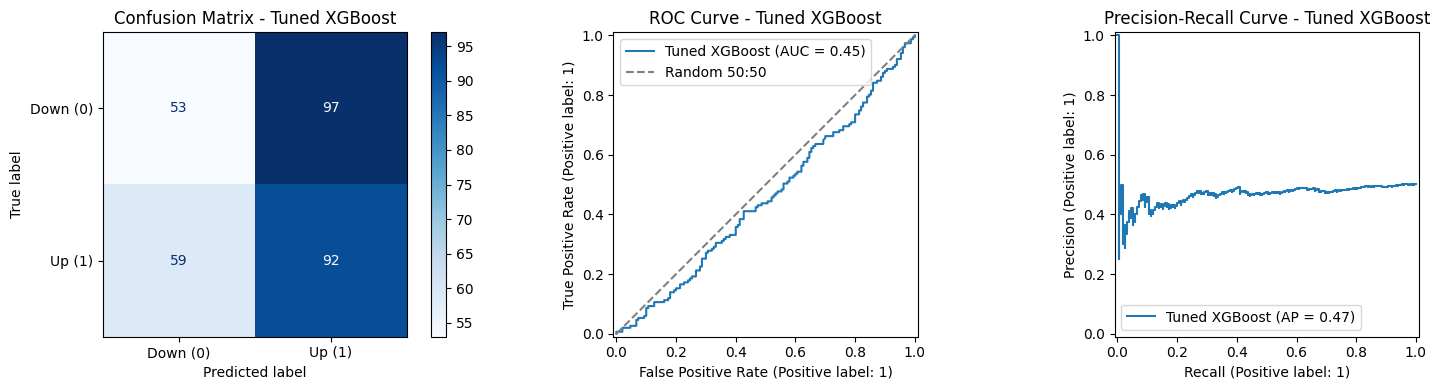

=== Tuned XGBoost Test Classification Report ===
              precision    recall  f1-score   support

    Down (0)       0.47      0.35      0.40       150
      Up (1)       0.49      0.61      0.54       151

    accuracy                           0.48       301
   macro avg       0.48      0.48      0.47       301
weighted avg       0.48      0.48      0.47       301



In [132]:
# C.3(c) Tuned model evaluation: confusion matrix, ROC, PR curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=['Down (0)', 'Up (1)'],
    cmap=plt.cm.Blues,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Tuned XGBoost')

# ROC Curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    name='Tuned XGBoost',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random 50:50')
axes[1].set_title('ROC Curve - Tuned XGBoost')
axes[1].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    name='Tuned XGBoost',
    ax=axes[2]
)
axes[2].set_title('Precision-Recall Curve - Tuned XGBoost')

plt.tight_layout()
plt.show()

# Classification Report
print("=== Tuned XGBoost Test Classification Report ===")
print(classification_report(
    y_test,
    y_test_pred_tuned,
    target_names=['Down (0)', 'Up (1)']
))

The confusion matrix and classification report also show weak class-level performance. The model captures more up moves than down moves, but precision remains low and overall balanced accuracy is only 48.13%. Therefore, despite hyperparameter tuning, the model is not suitable for live trade deployment. The result suggests that the selected features do not contain a stable next-day predictive signal for GLD over the test period.

Given the model's accuracy, and the current state of not being deployable, we are running a robustness check to examine if the poor results were contributed by the 17 feature we have selected.

In [133]:
# Compare 39-feature, 20-feature and 17-feature versions using the same tuned XGBoost parameters

feature_sets = {
    'Correlation only - 39 features': (X_train_corr, X_test_corr),
    'SHAP selected - 20 features': (X_train_stage2, X_test_stage2),
    'Final embedded - 17 features': (X_train_final, X_test_final)
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

results = []

for name, (Xtr, Xte) in feature_sets.items():

    model = XGBClassifier(
        **search.best_params_,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        verbosity=0
    )

    model.fit(Xtr, y_train, sample_weight=sample_weights)

    # Train predictions
    ytr_pred = model.predict(Xtr)
    ytr_proba = model.predict_proba(Xtr)[:, 1]

    # Test predictions
    yte_pred = model.predict(Xte)
    yte_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        'Feature Set': name,
        'N Features': Xtr.shape[1],
        'Train ROC-AUC': roc_auc_score(y_train, ytr_proba),
        'Test ROC-AUC': roc_auc_score(y_test, yte_proba),
        'Test Accuracy': accuracy_score(y_test, yte_pred),
        'Test Balanced Accuracy': balanced_accuracy_score(y_test, yte_pred),
        'Test Precision': precision_score(y_test, yte_pred, zero_division=0),
        'Test Recall': recall_score(y_test, yte_pred, zero_division=0),
        'Test F1': f1_score(y_test, yte_pred, zero_division=0)
    })

feature_compare_df = pd.DataFrame(results).sort_values(
    'Test ROC-AUC', ascending=False
).reset_index(drop=True)

feature_compare_df.round(4)

,Feature Set,N Features,Train ROC-AUC,Test ROC-AUC,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1
0,Correlation only - 39 features,39,0.6824,0.4812,0.4950,0.4951,0.4966,0.4768,0.4865
1,SHAP selected - 20 features,20,0.6515,0.4708,0.4850,0.4845,0.4898,0.6358,0.5533
2,Final embedded - 17 features,17,0.6591,0.4546,0.4817,0.4813,0.4868,0.6093,0.5412


Although the 39-feature set performed marginally better, all feature sets were still producing ROC-AUC results below 0.50 ROC-AUC. Therefore, we can conclude  changing the final feature-selection cutoff will not materially improve the outcome.

Secondly, we want to check if the weak results were specific to XGBoost model's behavior and complexity

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Time-series CV with 1-period gap
tscv = TimeSeriesSplit(n_splits=5, gap=1)

# Sample weights from training labels only
sample_weights_logit = compute_sample_weight(class_weight='balanced', y=y_train)

# RobustScaler is used because financial features can contain outliers
logit_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

# Regularisation grid
param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs'],
        'clf__C': np.logspace(-3, 2, 12)
    },
    {
        'clf__penalty': ['l1'],
        'clf__solver': ['liblinear'],
        'clf__C': np.logspace(-3, 2, 12)
    }
]

logit_search = GridSearchCV(
    estimator=logit_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=-1,
    verbose=0
)

logit_search.fit(
    X_train_final,
    y_train,
    clf__sample_weight=sample_weights_logit
)

print(f"Best Logistic CV ROC-AUC: {logit_search.best_score_:.4f}")
print("Best parameters:")
print(logit_search.best_params_)

Best Logistic CV ROC-AUC: 0.5328
Best parameters:
{'clf__C': np.float64(0.0657933224657568), 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


In [135]:
best_logit = logit_search.best_estimator_

# Training predictions
y_train_pred_logit = best_logit.predict(X_train_final)
y_train_proba_logit = best_logit.predict_proba(X_train_final)[:, 1]

# Test predictions
y_test_pred_logit = best_logit.predict(X_test_final)
y_test_proba_logit = best_logit.predict_proba(X_test_final)[:, 1]

print("=== Logistic Regression with RobustScaler: Training Performance ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred_logit):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred_logit):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_train, y_train_proba_logit):.4f}")

print("\n=== Logistic Regression with RobustScaler: Test Performance ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred_logit):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred_logit):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_test_proba_logit):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_logit,
    target_names=['Down (0)', 'Up (1)']
))

=== Logistic Regression with RobustScaler: Training Performance ===
Accuracy:          0.4908
Balanced Accuracy: 0.5339
ROC-AUC:           0.5908

=== Logistic Regression with RobustScaler: Test Performance ===
Accuracy:          0.5249
Balanced Accuracy: 0.5235
ROC-AUC:           0.4946

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.65      0.10      0.17       150
      Up (1)       0.51      0.95      0.67       151

    accuracy                           0.52       301
   macro avg       0.58      0.52      0.42       301
weighted avg       0.58      0.52      0.42       301



As an additional benchmark, a regularised logistic regression model with RobustScaler was tested. This model slightly improved test accuracy and balanced accuracy relative to the tuned XGBoost model, achieving 52.49% accuracy and 52.35% balanced accuracy. <br>

However, the ROC-AUC remained below 0.50 at 0.4946, indicating that the model still does not reliably rank positive next-day GLD moves. The classification report shows that the model strongly favours the up class, with high recall for class 1 but weak recall for class 0. Therefore, while logistic regression provides a marginally better benchmark, it does not change the overall conclusion, the model is not deployable to trade.

In [136]:
feature_sets = {
    'Correlation only - 39 features': (X_train_corr, X_test_corr),
    'SHAP selected - 20 features': (X_train_stage2, X_test_stage2),
    'Final embedded - 17 features': (X_train_final, X_test_final)
}

logit_results = []

for name, (Xtr, Xte) in feature_sets.items():

    sample_weights_tmp = compute_sample_weight(class_weight='balanced', y=y_train)

    logit_search_tmp = GridSearchCV(
        estimator=logit_pipe,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=tscv,
        n_jobs=-1,
        verbose=0
    )

    logit_search_tmp.fit(
        Xtr,
        y_train,
        clf__sample_weight=sample_weights_tmp
    )

    model = logit_search_tmp.best_estimator_

    ytr_proba = model.predict_proba(Xtr)[:, 1]
    yte_pred = model.predict(Xte)
    yte_proba = model.predict_proba(Xte)[:, 1]

    logit_results.append({
        'Feature Set': name,
        'N Features': Xtr.shape[1],
        'Best CV ROC-AUC': logit_search_tmp.best_score_,
        'Train ROC-AUC': roc_auc_score(y_train, ytr_proba),
        'Test ROC-AUC': roc_auc_score(y_test, yte_proba),
        'Test Accuracy': accuracy_score(y_test, yte_pred),
        'Test Balanced Accuracy': balanced_accuracy_score(y_test, yte_pred),
        'Best Params': logit_search_tmp.best_params_
    })

logit_compare_df = pd.DataFrame(logit_results).sort_values(
    'Test ROC-AUC',
    ascending=False
).reset_index(drop=True)

logit_compare_df

,Feature Set,N Features,Best CV ROC-AUC,Train ROC-AUC,Test ROC-AUC,Test Accuracy,Test Balanced Accuracy,Best Params
0,Final embedded - 17 features,17,0.532785,0.590836,0.494570,0.524917,0.523510,"{'clf__C': 0.0657933224657568, 'clf__penalty':..."
1,SHAP selected - 20 features,20,0.527158,0.590189,0.489934,0.501661,0.500177,"{'clf__C': 0.02310129700083159, 'clf__penalty'..."
2,Correlation only - 39 features,39,0.513127,0.602141,0.485298,0.504983,0.503466,"{'clf__C': 0.02310129700083159, 'clf__penalty'..."


The robustness check across alternative feature subsets produced similar results. Although the 17-feature, 20-feature, and 39-feature sets generated small differences in accuracy and ROC-AUC, none produced materially strong testing period predictability. This suggests that the poor model performance is not driven solely by the final 17-feature selection step.

### **Backtesting (Optional portion)**

As an optional diagnostic, a simple long-only backtest was performed using the tuned XGBoost signal. The strategy goes long GLD when the model predicts class 1 and otherwise holds cash. <br>

To better simulate a live trade environment, a 5 bps transaction cost is applied whenever a transaction occurs. Traditional evaluation metrics e.g. Sharpe Ratio, annualized return and maximum drawdown will be computed to facilitate full analysis. <br>

The purpose of this backtest is not to identify if the model is tradable or how to optimize a trading strategy, but to understand whether the weak classification results translate into poor trading behaviour through missed trends, excessive turnover, or insufficient hit rate after costs. Where feasible, we will also attempt to roughly estimate at what accuracy level, we may get a deployable model.

In [137]:
# helper functions for backtest purposes
def max_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown.min()

def annualized_sharpe(log_returns, periods_per_year=252):
    simple_returns = np.exp(log_returns) - 1
    if simple_returns.std() == 0:
        return np.nan
    return np.sqrt(periods_per_year) * simple_returns.mean() / simple_returns.std()

def annualized_return(equity_curve, periods_per_year=252):
    n_periods = len(equity_curve)
    total_return = equity_curve.iloc[-1] / equity_curve.iloc[0] - 1
    return (1 + total_return) ** (periods_per_year / n_periods) - 1

In [138]:
# prepare backtest framework
full_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/features_engineered.csv', index_col=0, parse_dates=True)

full_data = full_data.loc['2020':'2025'].copy()
full_data['Forward_LogRet_1d'] = full_data['GLD_LogRet'].shift(-1)

bt = pd.DataFrame(index=X_test.index)
bt['Forward_LogRet_1d'] = full_data.loc[X_test.index, 'Forward_LogRet_1d']

# Model signal: long when tuned XGBoost predicts Up, otherwise cash
bt['Signal'] = y_test_pred_tuned.astype(int)
bt = bt.dropna().copy()

In [139]:
# Strategy construction
tcost = 0.0005  # 5 bps per position change

bt['Turnover'] = bt['Signal'].diff().abs().fillna(bt['Signal'])

bt['Strategy_Gross_LogRet'] = bt['Signal'] * bt['Forward_LogRet_1d']
bt['Transaction_Cost'] = tcost * bt['Turnover']
bt['Strategy_Net_LogRet'] = bt['Strategy_Gross_LogRet'] - bt['Transaction_Cost']
bt['BuyHold_LogRet'] = bt['Forward_LogRet_1d']

bt['Strategy_Gross_Equity'] = np.exp(bt['Strategy_Gross_LogRet'].cumsum())
bt['Strategy_Net_Equity'] = np.exp(bt['Strategy_Net_LogRet'].cumsum())
bt['BuyHold_Equity'] = np.exp(bt['BuyHold_LogRet'].cumsum())

In [140]:
# Summary statistics

n_days = len(bt)
n_long_days = bt['Signal'].sum()
n_trades = bt['Turnover'].sum()
turnover_rate = n_trades / n_days

hit_rate_when_long = (bt.loc[bt['Signal'] == 1, 'Forward_LogRet_1d'] > 0).mean()

summary = pd.DataFrame({'Metric': ['Test Days', 'Long Days', 'Long Exposure', 'Number of Trades', 'Turnover Rate', 'Hit Rate When Long', 'Total Return', 'Annualized Return', 'Sharpe Ratio', 'Max Drawdown'],
                        'Model Strategy - Net': [n_days, n_long_days, n_long_days / n_days, n_trades, turnover_rate, hit_rate_when_long,
                                                 bt['Strategy_Net_Equity'].iloc[-1] - 1, annualized_return(bt['Strategy_Net_Equity']), annualized_sharpe(bt['Strategy_Net_LogRet']),
                                                 max_drawdown(bt['Strategy_Net_Equity'])],
                        'Buy-and-Hold GLD': [n_days, np.nan, 1.0, np.nan, np.nan, np.nan, bt['BuyHold_Equity'].iloc[-1] - 1, annualized_return(bt['BuyHold_Equity']),
                                             annualized_sharpe(bt['BuyHold_LogRet']), max_drawdown(bt['BuyHold_Equity'])]})

# Display formatting
percent_metrics = ['Long Exposure', 'Turnover Rate', 'Hit Rate When Long', 'Total Return', 'Annualized Return', 'Max Drawdown']
summary_display = summary.copy()

for col in ['Model Strategy - Net', 'Buy-and-Hold GLD']:
    summary_display[col] = summary_display.apply(
        lambda row:
            f"{row[col]:.2%}" if row['Metric'] in percent_metrics and pd.notna(row[col])
            else f"{row[col]:.2f}" if row['Metric'] == 'Sharpe Ratio' and pd.notna(row[col])
            else f"{row[col]:.0f}" if pd.notna(row[col])
            else "",
        axis=1)

summary_display

,Metric,Model Strategy - Net,Buy-and-Hold GLD
0,Test Days,300,300
1,Long Days,188,
2,Long Exposure,62.67%,100.00%
3,Number of Trades,119,
4,Turnover Rate,39.67%,
5,Hit Rate When Long,57.98%,
6,Total Return,7.11%,61.28%
7,Annualized Return,5.46%,48.66%
8,Sharpe Ratio,0.44,2.16
9,Max Drawdown,-10.95%,-10.13%


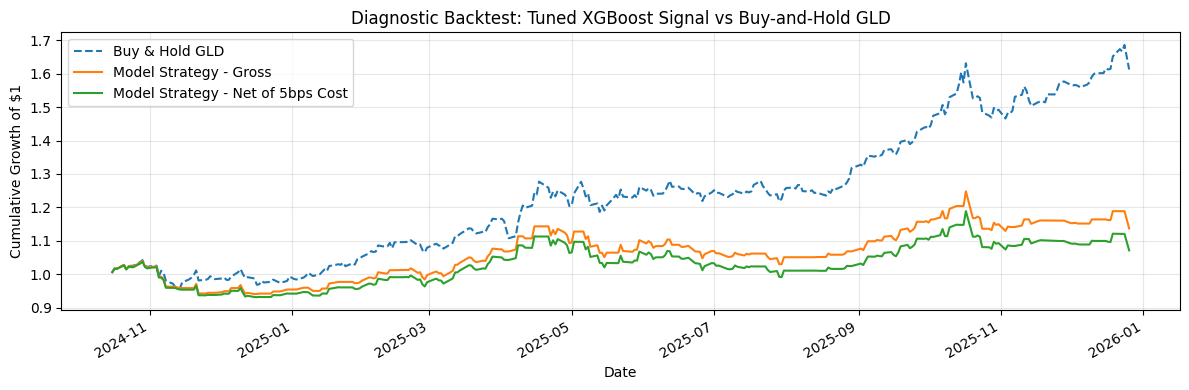

In [141]:
fig, ax = plt.subplots(figsize=(12, 4))

bt['BuyHold_Equity'].plot(ax=ax, label='Buy & Hold GLD', linestyle='--')
bt['Strategy_Gross_Equity'].plot(ax=ax, label='Model Strategy - Gross')
bt['Strategy_Net_Equity'].plot(ax=ax, label='Model Strategy - Net of 5bps Cost')

ax.set_title('Diagnostic Backtest: Tuned XGBoost Signal vs Buy-and-Hold GLD')
ax.set_ylabel('Cumulative Growth of $1')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [142]:
# Estimating accuracy to breakeven
trade_rets = bt.loc[bt['Signal'] == 1, 'Forward_LogRet_1d']

avg_win = trade_rets[trade_rets > 0].mean()
avg_loss = -trade_rets[trade_rets < 0].mean()

# Approximate average cost per long day
avg_cost_per_long_day = bt['Transaction_Cost'].sum() / max(n_long_days, 1)

breakeven_hit_rate = (avg_loss + avg_cost_per_long_day) / (avg_win + avg_loss)

print("=== Break-even Hit Rate Estimate ===")
print(f"Average win on long days:       {avg_win:.4%}")
print(f"Average loss on long days:      {avg_loss:.4%}")
print(f"Avg cost per long day:          {avg_cost_per_long_day:.4%}")
print(f"Actual hit rate when long:      {hit_rate_when_long:.2%}")
print(f"Estimated break-even hit rate:  {breakeven_hit_rate:.2%}")

=== Break-even Hit Rate Estimate ===
Average win on long days:       0.8699%
Average loss on long days:      1.0380%
Avg cost per long day:          0.0316%
Actual hit rate when long:      57.98%
Estimated break-even hit rate:  56.06%


The diagnostic backtest for testing period shows that the model’s long predictions had a 57.98% hit rate, slightly above the estimated break-even range. However, this did not translate into good trading performance. After transaction cost, strategy return was only 7.11%, underperform 61.28% returns for GLD in buy-and-hold over same period. The strategy also produced a much lower Sharpe ratio, 0.44 versus 2.16 for buy-and-hold, while its maximum drawdown was similar (i.e. no advantage nor drawdown risk cover provided). This suggests that the model’s main weakness is not only directional accuracy, but poor exit timing. The strategy trades frequent enough but misses much of the sustained GLD rally.

Conclusion to 3c) <br>
The tuned XGBoost model does not show strong out-of-sample prediction quality. Test ROC-AUC is 0.4546, below the random benchmark of 0.50, while accuracy and balanced accuracy are also below 50%. The confusion matrix and classification report show weak class-level performance, with low precision and unstable recall across the two classes. This indicates that, despite hyperparameter tuning, the model does not reliably classify next-day GLD up moves in the unseen test period.

## **VII) Project Conclusion**

This project aims to develop a supervised machine-learning framework to predict positive next-day market moves in GLD using a binary classification target. The target was defined as (1) when next-day GLD log return exceeded +0.20%, and (0) otherwise, treating small positive moves as economically insignificant noise.

The analysis began with a broad data extraction and feature-engineering process covering GLD technical indicators, volatility and volume measures, macro/rates variables, cross-asset gold-related indicators, and CFTC positioning data. A chronological train-test split with a one-trading-day purge gap was used to preserve time ordering and avoid look-ahead bias. Feature selection was then performed using a three-stage funneling approach fitted only on the training sample: pairwise correlation filtering, SHAP-guided XGBoost wrapper-style ranking, and XGBoost gain-based embedded selection. This reduced the original 47 engineered features to a final 17-feature subset while retaining economically interpretable drivers across technical, macro, rates, commodity, and cross-asset categories.

The final XGBoost model was trained and tuned using time-series cross-validation. Although hyperparameter tuning reduced the degree of in-sample overfitting, the model failed to generalize to the unseen 2024–2025 test period. The tuned model’s test ROC-AUC was below 0.50, and additional robustness checks using alternative feature subsets and additional model baseline check using logistic regression did not materially improve prediction quality.

Overall, the workflow provides a structured machine-learning workflow for feature engineering, feature selection, model tuning, out-of-sample evaluation and backtesting to simulate live trading environment. However, for the selected GLD dataset, at one-day-ahead prediction horizon, and with +0.20% uptrend target, the evidence does not support deployment of the model in live trade. The results are consistent with the difficulty of predicting short-horizon asset returns, where apparent training-period patterns may be weak, unstable, or regime-dependent.
